# Singleworm Tracking

## A Note on Prompt Frames
The original author's scripts used a **"prompt frame" strategy**: reference JPEG images with a worm at a known pixel location were appended to each video directory, along with a `prompt_data.json` file mapping frame numbers to click coordinates. SAM2 was then told "there's a worm at these coordinates in the appended frame" and segmentation was propagated **backward** through the real video frames. This avoided manually prompting each video — the same reference images and coordinates worked for all of them.

**The problem:** Neither the prompt frame images nor the `prompt_data.json` file for `singleworm_tracking` were committed to the repository. The `prompt_frames/` directory is empty and no `singleworm_tracking/prompt_data.json` exists. These assets only existed on the original author's local machine, so the full-frame segmentation cell (cell 19) will fail as-is.

**Recommended fix:** Replace the prompt-frame-appending approach with direct prompting on a real video frame (e.g., the middle frame) and propagate in both directions, as was done in the `droplet_swimming` notebook. This is simpler, doesn't require missing assets, and follows the standard SAM2 workflow. The only requirement is picking a frame where the worm is clearly visible and providing its `(x, y)` pixel coordinates.

## Notebook Setup
In this section, we'll set ourselves up for success by setting up our Python environment appropriately, importing the Python libraries we'll be using, and downloading the raw data from Google Drive.

In [1]:
# Importing the necessary Python libraries
from __future__ import annotations

import copy
import gc
import json
import math
import os
import pickle
import re
import shutil
import time
import zipfile
from collections import defaultdict
from pathlib import Path

import cv2
import gdown
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import tifffile
import torch
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from PIL import Image
from scipy import interpolate, ndimage
from scipy.ndimage import binary_dilation, binary_fill_holes, center_of_mass
from scipy.optimize import linear_sum_assignment
from scipy.signal import find_peaks, medfilt, savgol_filter, welch
from scipy.spatial.distance import cdist, euclidean
from skimage import graph, measure, morphology
from skimage.morphology import skeletonize
from tqdm import tqdm

from sam2.build_sam import build_sam2_video_predictor_hf

In [2]:
# Setting the root of the working directory
WORK_DIR_ROOT = '..'

# Setting the working directories used throughout this notebook
raw_files_dir = f'{WORK_DIR_ROOT}/data/raw_files'
processed_files_dir = f'{WORK_DIR_ROOT}/data/processed_files/singleworm_tracking'
frames_dir = Path(processed_files_dir) / 'frames'
segmentation_dir = Path(processed_files_dir) / 'segmentation'
hd_segmentation_dir = Path(processed_files_dir) / 'hd_segmentation'
shape_analysis_dir = Path(processed_files_dir) / 'shape_analysis'
path_analysis_dir = Path(processed_files_dir) / 'path_analysis'
plots_dir = Path(processed_files_dir) / 'plots'
prompt_frames_dir = Path(processed_files_dir) / 'prompt_frames'

# Creating required directories (if not already created)
os.makedirs(raw_files_dir, exist_ok=True)
for d in [frames_dir, segmentation_dir, hd_segmentation_dir, shape_analysis_dir,
          path_analysis_dir, plots_dir, prompt_frames_dir]:
    d.mkdir(parents=True, exist_ok=True)

## Downloading the Raw TIFF Files

In [3]:
# Setting the raw Google Drive doc ID and file URL
RAW_FILE_DOC_ID = '1UTYRcgheRP1eMXw71CNgh9-em2MigdDb'
gdrive_file_url = f'https://drive.google.com/uc?id={RAW_FILE_DOC_ID}'

# Checking whether raw files are already present (ignoring .gitkeep)
existing_raw_files = [
    path for path in Path(raw_files_dir).iterdir() if path.name != '.gitkeep'
 ]

# Downloading and extracting only when the raw files directory is empty or only has .gitkeep
if not existing_raw_files:

    # Downloading the raw files from Google Drive
    gdown.download(
        url = gdrive_file_url,
        output = f'{raw_files_dir}/samples.zip'
    )

    # Setting the .zip filepath
    zip_path = Path(f'{raw_files_dir}/samples.zip')

    # Setting the prefix associated to all the raw TIF files
    RAW_FILE_PREFIX = "06.27.25 CONFOCAL VID_DYS1AH DAY 5 CRAWL "

    # Interacting with the ZIP file downloaded from Google Drive
    with zipfile.ZipFile(zip_path) as z:

        # Iterating over each TIF file in the raw ZIP
        for member in z.namelist():

            # Checking if the file is in the "sample images/" directory and ends with ".tif"
            if member.startswith('sample images/') and member.endswith('.tif'):

                # Getting the original name of the file
                original_name = Path(member).name

                # Setting a new name for the file by stripping the prefix from the file
                new_name = original_name.replace(RAW_FILE_PREFIX, '', 1)

                # Extracting the contents of the file from the ZIP
                target = zip_path.parent / new_name
                with z.open(member) as src, open(target, 'wb') as destination:
                    destination.write(src.read())

    # Deleting the original ZIP file as it is no longer needed
    zip_path.unlink()
else:
    print('Raw files already exist in raw_files_dir; skipping download and extraction.')

Raw files already exist in raw_files_dir; skipping download and extraction.


## Processing TIFFs into JPEG Frame Directories
Each raw TIFF stack is converted into a dedicated directory of numbered JPEG frames. Global min/max normalization is applied across all frames within each stack to preserve relative brightness.

In [4]:
# Checking whether processed frame directories already exist (ignoring .gitkeep)
existing_processed_files = [
    path for path in Path(frames_dir).iterdir()
    if path.name != '.gitkeep'
]

# Processing raw TIFF files only when the processed directory is empty
if not existing_processed_files:

    # Iterating over all raw TIFF files
    for raw_file_name in sorted(os.listdir(raw_files_dir)):

        # Skipping non-TIFF files
        if not raw_file_name.lower().endswith(('.tif', '.tiff')):
            continue

        tiff_path = os.path.join(raw_files_dir, raw_file_name)

        with tifffile.TiffFile(tiff_path) as tif:
            total_frames = len(tif.pages)
            if total_frames == 0:
                print(f'Skipping {raw_file_name}: empty TIFF')
                continue

            # Computing global min/max across all frames for consistent brightness normalization
            global_min = float('inf')
            global_max = float('-inf')
            for page in tif.pages:
                frame = page.asarray()
                global_min = min(global_min, float(np.min(frame)))
                global_max = max(global_max, float(np.max(frame)))

            # Creating an output directory named after the TIFF stem
            raw_file_stem = Path(raw_file_name).stem
            video_output_dir = frames_dir / raw_file_stem
            video_output_dir.mkdir(parents=True, exist_ok=True)

            # Exporting each frame as a globally-normalized JPEG
            for frame_idx in range(total_frames):
                frame = tif.pages[frame_idx].asarray()

                if global_max == global_min:
                    frame_8bit = np.zeros_like(frame, dtype=np.uint8)
                else:
                    frame_adjusted = frame.astype(np.float64) - global_min
                    scaling_factor = 255.0 / (global_max - global_min)
                    frame_8bit = (frame_adjusted * scaling_factor).astype(np.uint8)

                # Converting grayscale to BGR for consistent JPEG output
                if frame_8bit.ndim == 2:
                    frame_8bit = cv2.cvtColor(frame_8bit, cv2.COLOR_GRAY2BGR)

                dest_path = video_output_dir / f'{frame_idx:06d}.jpg'
                cv2.imwrite(str(dest_path), frame_8bit, [cv2.IMWRITE_JPEG_QUALITY, 95])

            print(f'Converted {raw_file_name}: {total_frames} frames -> {video_output_dir.name}/')
else:
    print('Processed frame directories already exist; skipping TIFF-to-JPEG conversion.')

Converted 5_t065_ch01.tif: 1 frames -> 5_t065_ch01/
Converted 5_t065_ch02.tif: 1 frames -> 5_t065_ch02/
Converted 5_t065_ch03.tif: 1 frames -> 5_t065_ch03/
Converted 5_t066_ch00.tif: 1 frames -> 5_t066_ch00/
Converted 5_t066_ch01.tif: 1 frames -> 5_t066_ch01/
Converted 5_t066_ch02.tif: 1 frames -> 5_t066_ch02/
Converted 5_t066_ch03.tif: 1 frames -> 5_t066_ch03/
Converted 5_t067_ch00.tif: 1 frames -> 5_t067_ch00/
Converted 5_t067_ch01.tif: 1 frames -> 5_t067_ch01/
Converted 5_t067_ch02.tif: 1 frames -> 5_t067_ch02/
Converted 5_t067_ch03.tif: 1 frames -> 5_t067_ch03/
Converted 5_t068_ch00.tif: 1 frames -> 5_t068_ch00/
Converted 5_t068_ch01.tif: 1 frames -> 5_t068_ch01/
Converted 5_t068_ch02.tif: 1 frames -> 5_t068_ch02/
Converted 5_t068_ch03.tif: 1 frames -> 5_t068_ch03/
Converted 5_t069_ch00.tif: 1 frames -> 5_t069_ch00/
Converted 5_t069_ch01.tif: 1 frames -> 5_t069_ch01/
Converted 5_t069_ch02.tif: 1 frames -> 5_t069_ch02/
Converted 5_t069_ch03.tif: 1 frames -> 5_t069_ch03/
Converted 5_

In [5]:
# Listing all available video frame directories
video_dirs = sorted([
    d for d in frames_dir.iterdir()
    if d.is_dir() and d.name != '.gitkeep'
])

if not video_dirs:
    raise FileNotFoundError(
        f'No video frame directories found in: {frames_dir}'
    )

# Selecting the first available video directory for processing
video_frames_dir = video_dirs[0]
video_folder_name = video_frames_dir.name
print(f'Available video directories: {[d.name for d in video_dirs]}')
print(f'Selected test video: {video_folder_name}')

# Counting available frames
frame_names = sorted(
    [f for f in os.listdir(video_frames_dir) if f.lower().endswith(('.jpg', '.jpeg'))],
    key=lambda p: int(os.path.splitext(p)[0])
)
print(f'Total frames: {len(frame_names)}')

Available video directories: ['5_t065_ch01', '5_t065_ch02', '5_t065_ch03', '5_t066_ch00', '5_t066_ch01', '5_t066_ch02', '5_t066_ch03', '5_t067_ch00', '5_t067_ch01', '5_t067_ch02', '5_t067_ch03', '5_t068_ch00', '5_t068_ch01', '5_t068_ch02', '5_t068_ch03', '5_t069_ch00', '5_t069_ch01', '5_t069_ch02', '5_t069_ch03', '5_t070_ch00', '5_t070_ch01', '5_t070_ch02', '5_t129_ch02', '5_t129_ch03', '5_t130_ch00', '5_t130_ch01', '5_t130_ch02', '5_t130_ch03', '5_t131_ch00', '5_t131_ch01', '5_t131_ch02', '5_t131_ch03', '5_t132_ch00', '5_t132_ch01', '5_t132_ch02', '5_t132_ch03', '5_t133_ch00', '5_t133_ch01', '5_t133_ch02', '5_t133_ch03', '5_t134_ch00', '5_t134_ch01', '5_t134_ch02', '5_t134_ch03']
Selected test video: 5_t065_ch01
Total frames: 1


### Loading a Test Frame

Sample frame: 000000.jpg
Frame size: (128, 128)


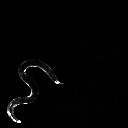

In [6]:
# Loading a sample frame from the middle of the selected video for visualization
sample_frame_path = os.path.join(str(video_frames_dir), frame_names[len(frame_names) // 2])
sample_frame = cv2.imread(sample_frame_path)

if sample_frame is None:
    raise FileNotFoundError(f'Could not load sample frame: {sample_frame_path}')

print(f'Sample frame: {frame_names[len(frame_names) // 2]}')
print(f'Frame size: {sample_frame.shape[:2]}')
Image.fromarray(cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB))

## Autoprompted Segmentation with SAM2
Using Meta's SAM2 video predictor, we perform two-pass segmentation: first a full-frame pass using generic prompt frames, then a high-definition pass on cropped regions around the detected worm.

### Loading the SAM2 Video Predictor from Hugging Face

In [7]:
# Detecting the hardware device
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.autocast(device_type='cuda', dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Current hardware device type: {device}')

# Loading the SAM2 video predictor from Hugging Face
predictor = build_sam2_video_predictor_hf('facebook/sam2.1-hiera-large', device=device)

Current hardware device type: mps


### Creating Helper Functions for Segmentation

In [8]:
# Rendering a colored mask overlay on a matplotlib axis
def show_mask(mask, ax, obj_id=None, random_color=False):
    color = (np.concatenate([np.random.random(3), np.array([0.6])], axis=0) if random_color
             else np.array([*plt.get_cmap('tab10')(0 if obj_id is None else obj_id)[:3], 0.6]))
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


# Rendering prompt points (positive/negative) on a matplotlib axis
def show_points(coords, labels, ax, marker_size=26):
    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*',
               s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*',
               s=marker_size, edgecolor='white', linewidth=1.25)


# Copying prompt frames into the video directory and returning a frame mapping
def add_prompt_frames_to_video(video_dir, prompt_dir):
    existing_frames = [f for f in os.listdir(video_dir) if f.lower().endswith(('.jpg', '.jpeg'))]
    last_frame_num = max(int(os.path.splitext(f)[0]) for f in existing_frames)

    prompt_frames = sorted(
        [f for f in os.listdir(prompt_dir) if f.lower().endswith(('.jpg', '.jpeg'))],
        key=lambda x: int(os.path.splitext(x)[0])
    )

    frame_mapping = {}
    for i, prompt_frame in enumerate(prompt_frames, start=1):
        new_frame_num = last_frame_num + i
        new_frame_name = f'{new_frame_num:06d}.jpg'
        shutil.copy(os.path.join(prompt_dir, prompt_frame), os.path.join(video_dir, new_frame_name))
        frame_mapping[new_frame_num] = int(os.path.splitext(prompt_frame)[0])

    print(f'Added {len(prompt_frames)} prompt frames to the video directory.')
    return frame_mapping


# Removing prompt frames from the video directory after segmentation
def remove_prompt_frames_from_video(video_dir, frame_mapping):
    for frame_num in frame_mapping.keys():
        frame_path = os.path.join(video_dir, f'{frame_num:06d}.jpg')
        if os.path.exists(frame_path):
            os.remove(frame_path)
    print(f'Removed {len(frame_mapping)} prompt frames from the video directory.')


# Removing prompt-frame predictions from the video_segments dictionary
def filter_prompt_frames_from_segments(video_segments, frame_mapping):
    filtered_segments = {
        frame: segments for frame, segments in video_segments.items()
        if frame not in frame_mapping
    }
    print(f'Removed {len(frame_mapping)} prompt frames from video_segments dictionary.')
    return filtered_segments


# Adding prompts for a specific frame and object
def add_prompts(inference_state, frame_idx, obj_id, points, labels):
    _, out_obj_ids, out_mask_logits = predictor.add_new_points(
        inference_state=inference_state,
        frame_idx=frame_idx,
        obj_id=obj_id,
        points=points,
        labels=labels
    )
    return out_obj_ids, out_mask_logits


# Checking overlap between two masks and returning IoU and pixel count
def check_overlap(mask1, mask2):
    intersection = np.logical_and(mask1, mask2)
    union = np.logical_or(mask1, mask2)
    overlap_pixels = np.sum(intersection)
    iou = overlap_pixels / np.sum(union) if np.sum(union) > 0 else 0
    return overlap_pixels > 0, iou, overlap_pixels


# Analyzing masks across all frames for quality issues (empty, high-area, overlapping, low consecutive overlap)
def analyze_masks(video_segments):
    results = {'empty': {}, 'high': {}, 'overlapping': {}, 'low_consecutive_overlap': {}}

    for frame, mask_dict in video_segments.items():
        mask_ids = [mask_id for mask_id in mask_dict.keys() if mask_id is not None]
        empty_masks = set()

        for mask_id in mask_ids:
            mask = mask_dict[mask_id]
            if mask is not None:
                mask_sum = mask.sum()
                if mask_sum == 0:
                    results['empty'].setdefault(frame, []).append(mask_id)
                    empty_masks.add(mask_id)
                elif mask_sum >= 40000:
                    results['high'].setdefault(frame, []).append(mask_id)

        for i in range(len(mask_ids)):
            if mask_ids[i] in empty_masks:
                continue
            mask = mask_dict[mask_ids[i]]
            if mask is not None:
                for j in range(i + 1, len(mask_ids)):
                    if mask_ids[j] in empty_masks:
                        continue
                    other_mask = mask_dict[mask_ids[j]]
                    if other_mask is not None:
                        is_overlapping, iou, overlap_pixels = check_overlap(mask, other_mask)
                        if is_overlapping:
                            results['overlapping'].setdefault(frame, []).append(
                                (mask_ids[i], mask_ids[j], iou, overlap_pixels))

    # Checking consecutive frame overlap
    sorted_frames = sorted(video_segments.keys())
    for i in range(len(sorted_frames) - 1):
        current_frame = sorted_frames[i]
        next_frame = sorted_frames[i + 1]
        if next_frame - current_frame != 1:
            continue
        current_masks = video_segments[current_frame]
        next_masks = video_segments[next_frame]
        for obj_id in current_masks.keys():
            if (obj_id in next_masks and
                current_masks[obj_id] is not None and next_masks[obj_id] is not None and
                hasattr(current_masks[obj_id], 'sum') and hasattr(next_masks[obj_id], 'sum') and
                current_masks[obj_id].sum() > 0 and next_masks[obj_id].sum() > 0):
                is_overlapping, iou, _ = check_overlap(current_masks[obj_id], next_masks[obj_id])
                if iou < 0.20:
                    results['low_consecutive_overlap'].setdefault(next_frame, []).append(
                        (obj_id, current_frame, iou))

    return results


# Printing a summary of mask analysis results
def analyze_and_print_results(video_segments):
    analysis_results = analyze_masks(video_segments)
    total_frames = len(video_segments)

    for category in ['empty', 'high', 'overlapping', 'low_consecutive_overlap']:
        count = len(analysis_results[category])
        percentage = (count / total_frames) * 100 if total_frames > 0 else 0
        print(f'Frames with {category} masks: {count} out of {total_frames} ({percentage:.2f}%)')


# Filling single missing frames by interpolating between adjacent frames
def fill_single_missing_frames(video_segments):
    video_segments_copy = copy.deepcopy(video_segments)
    frame_indices = sorted(video_segments_copy.keys())
    if len(frame_indices) < 2:
        return video_segments_copy

    # Finding frames with empty masks
    empty_mask_frames = []
    for frame_idx in frame_indices:
        frame_masks = video_segments_copy[frame_idx]
        for obj_id, mask in frame_masks.items():
            if mask is not None and hasattr(mask, 'sum') and mask.sum() == 0:
                empty_mask_frames.append((frame_idx, obj_id))
                break

    # Finding frames with low consecutive overlap
    low_overlap_frames = []
    for i in range(len(frame_indices) - 1):
        current_frame = frame_indices[i]
        next_frame = frame_indices[i + 1]
        if next_frame - current_frame != 1:
            continue
        current_masks = video_segments_copy[current_frame]
        next_masks = video_segments_copy[next_frame]
        for obj_id in current_masks.keys():
            if (obj_id in next_masks and
                current_masks[obj_id] is not None and next_masks[obj_id] is not None and
                hasattr(current_masks[obj_id], 'sum') and hasattr(next_masks[obj_id], 'sum') and
                current_masks[obj_id].sum() > 0 and next_masks[obj_id].sum() > 0):
                is_overlapping, iou, _ = check_overlap(current_masks[obj_id], next_masks[obj_id])
                if iou < 0.20:
                    low_overlap_frames.append((next_frame, obj_id))

    if not empty_mask_frames and not low_overlap_frames:
        print('No frames with empty masks or low consecutive overlap detected.')
        return video_segments_copy

    print(f'Found {len(empty_mask_frames)} frames with empty masks')
    print(f'Found {len(low_overlap_frames)} frames with low consecutive overlap')

    filled_count = 0
    all_problematic = empty_mask_frames + low_overlap_frames
    for problem_frame, obj_id in all_problematic:
        # Finding previous and next valid frames
        prev_frame = None
        next_frame = None
        for fi in sorted([f for f in frame_indices if f < problem_frame], reverse=True):
            if (obj_id in video_segments_copy[fi] and
                video_segments_copy[fi][obj_id] is not None and
                hasattr(video_segments_copy[fi][obj_id], 'sum') and
                video_segments_copy[fi][obj_id].sum() > 0):
                prev_frame = fi
                break
        for fi in sorted([f for f in frame_indices if f > problem_frame]):
            if (obj_id in video_segments_copy[fi] and
                video_segments_copy[fi][obj_id] is not None and
                hasattr(video_segments_copy[fi][obj_id], 'sum') and
                video_segments_copy[fi][obj_id].sum() > 0):
                next_frame = fi
                break

        if prev_frame is not None and next_frame is not None:
            prev_mask = video_segments_copy[prev_frame][obj_id]
            next_mask = video_segments_copy[next_frame][obj_id]
            avg_mask = (prev_mask.astype(np.float32) + next_mask.astype(np.float32)) / 2.0
            avg_mask = avg_mask > 0.5 if prev_mask.dtype == bool else avg_mask.astype(prev_mask.dtype)
            video_segments_copy[problem_frame][obj_id] = avg_mask
            filled_count += 1
        elif prev_frame is not None:
            video_segments_copy[problem_frame][obj_id] = video_segments_copy[prev_frame][obj_id].copy()
            filled_count += 1
        elif next_frame is not None:
            video_segments_copy[problem_frame][obj_id] = video_segments_copy[next_frame][obj_id].copy()
            filled_count += 1

    print(f'Successfully filled {filled_count} problematic masks.')
    return video_segments_copy

### Running Full-Frame Segmentation
We add prompt frames to the video directory, initialize the SAM2 predictor, add prompts for each frame, and propagate the segmentation across all video frames.

In [9]:
# Setting the path to prompt frames and prompt data
# NOTE: prompt_frames_dir should contain reference JPEG frames with known worm locations
# NOTE: prompt_data_path should point to a JSON file mapping frame numbers to click prompts
prompt_data_path = Path(WORK_DIR_ROOT) / 'singleworm_tracking' / 'prompt_data.json'

# Adding prompt frames to the video directory
frame_mapping = add_prompt_frames_to_video(str(video_frames_dir), str(prompt_frames_dir))

# Re-reading the frame names after adding prompt frames
frame_names = sorted(
    [p for p in os.listdir(video_frames_dir) if p.lower().endswith(('.jpg', '.jpeg'))],
    key=lambda p: int(os.path.splitext(p)[0])
)

# Initializing the SAM2 inference state on the video directory
inference_state = predictor.init_state(video_path=str(video_frames_dir))

# Loading prompt data from JSON
with open(prompt_data_path, 'r') as f:
    prompt_data = json.load(f)

# Converting prompt data arrays to numpy
for frame_num in prompt_data:
    for obj_id in prompt_data[frame_num]:
        prompt_data[frame_num][obj_id]['points'] = np.array(
            prompt_data[frame_num][obj_id]['points'], dtype=np.float32)
        prompt_data[frame_num][obj_id]['labels'] = np.array(
            prompt_data[frame_num][obj_id]['labels'], dtype=np.int32)

# Adding prompts for each mapped frame
for new_frame_num, original_frame_num in frame_mapping.items():
    if str(original_frame_num) in prompt_data:
        for obj_id, obj_data in prompt_data[str(original_frame_num)].items():
            print(f'Processing frame {new_frame_num} (original {original_frame_num}), object {obj_id}')
            add_prompts(inference_state, new_frame_num, int(obj_id), obj_data['points'], obj_data['labels'])
            time.sleep(0.02)
    print(f'Completed frame {new_frame_num}')

# Propagating segmentation in reverse from the last prompt frame
video_segments = {}
last_frame_idx = max(frame_mapping.keys())
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(
    inference_state, start_frame_idx=last_frame_idx, reverse=True
):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

# Analyzing and cleaning up segmentation results
analyze_and_print_results(video_segments)
video_segments_filled = fill_single_missing_frames(video_segments)

# Removing prompt frames and filtering them from the segments
remove_prompt_frames_from_video(str(video_frames_dir), frame_mapping)
filtered_video_segments = filter_prompt_frames_from_segments(video_segments_filled, frame_mapping)

print(f'\nFinal segmented frames: {len(filtered_video_segments)}')

Added 0 prompt frames to the video directory.


frame loading (JPEG): 100%|██████████| 1/1 [00:00<00:00, 89.55it/s]


FileNotFoundError: [Errno 2] No such file or directory: '../singleworm_tracking/prompt_data.json'

### HD Segmentation
Now we perform a second, high-definition segmentation pass on tightly cropped regions around the worm detected in each frame.

In [ ]:
# Performing HD segmentation on cropped frames around each detected worm
def get_hdsegmentation(ffvideo_segments, video_dir, predictor, crop_size=94):
    hd_video_segments = {}
    cropped_dir = Path(video_dir).parent / 'cropped_temp'
    cropped_dir.mkdir(parents=True, exist_ok=True)

    for frame_num in sorted(ffvideo_segments.keys()):
        print(f'HD segmentation frame: {frame_num}')

        # Getting the full-frame mask for this frame
        or_mask = next(iter(ffvideo_segments[frame_num].values()))

        # Finding the crop box around the detected segment
        rows, cols = np.where(or_mask[0])
        if len(rows) == 0:
            continue
        center_y, center_x = rows.mean(), cols.mean()

        or_frame = cv2.imread(os.path.join(video_dir, f'{frame_num:06d}.jpg'))
        or_shape = or_frame.shape[:2]

        top = max(0, int(center_y - crop_size // 2))
        bottom = min(or_shape[0], top + crop_size)
        left = max(0, int(center_x - crop_size // 2))
        right = min(or_shape[1], left + crop_size)

        cropped_arr = or_frame[top:bottom, left:right]

        # Saving the cropped frame to a temporary directory for prediction
        cv2.imwrite(str(cropped_dir / f'{frame_num:06d}.jpg'), cropped_arr)

        # Initializing the predictor on the cropped frame directory
        if frame_num == sorted(ffvideo_segments.keys())[0]:
            crop_inference_state = predictor.init_state(video_path=str(cropped_dir))
        else:
            predictor.reset_state(crop_inference_state)
            crop_inference_state = predictor.init_state(video_path=str(cropped_dir))

        # Adding click prompts on the cropped frame
        ann_frame_idx = 0
        ann_obj_id = 1
        points = np.array([[crop_size // 2, crop_size // 2]], dtype=np.float32)
        labels = np.array([1], np.int32)
        predictor.add_new_points(
            inference_state=crop_inference_state,
            frame_idx=ann_frame_idx,
            obj_id=ann_obj_id,
            points=points,
            labels=labels,
        )

        # Propagating the prediction
        crop_video_segments = {}
        for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(crop_inference_state):
            crop_video_segments[out_frame_idx] = {
                out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
                for i, out_obj_id in enumerate(out_obj_ids)
            }

        # Getting the cropped HD segment and mapping back to full frame
        if 0 in crop_video_segments and 1 in crop_video_segments[0]:
            cropped_hd_segment = crop_video_segments[0][1]
            full_hd_segment = np.zeros(or_shape, dtype=bool)
            full_hd_segment[top:bottom, left:right] = cropped_hd_segment[0] if cropped_hd_segment.ndim == 3 else cropped_hd_segment
            reshaped_hdseg = np.expand_dims(full_hd_segment, axis=0)
            hd_video_segments[frame_num] = {1: reshaped_hdseg}

    # Cleaning up the temporary directory
    shutil.rmtree(cropped_dir, ignore_errors=True)

    return hd_video_segments


# Running HD segmentation on the filtered full-frame segments
hd_video_segments = get_hdsegmentation(
    filtered_video_segments, str(video_frames_dir), predictor, crop_size=94
)

# Analyzing and filling any missing HD frames
analyze_and_print_results(hd_video_segments)
hd_video_segments_filled = fill_single_missing_frames(hd_video_segments)

# Saving HD segments for downstream use
video_folder_name = os.path.basename(os.path.normpath(str(video_frames_dir)))
hd_output_path = hd_segmentation_dir / f'{video_folder_name}_hd_segments.pkl'
with open(hd_output_path, 'wb') as f:
    pickle.dump(hd_video_segments_filled, f)

print(f'Saved HD video segments to: {hd_output_path}')
print(f'HD segmented frames: {len(hd_video_segments_filled)}')

## Shape Analysis
With HD segmentation masks for each frame, we extract the worm skeleton, identify head and tail positions, and compute per-frame shape metrics including curvature, worm length, wavelength, and head bend angle.

### Creating Helper Functions for Shape Analysis

In [ ]:
# Custom exception for skeleton discontinuity issues
class DiscontinuousSkeletonError(Exception):
    pass


# Smoothing a metric time series with a Savitzky-Golay filter
def smooth_metric(data, window_length=11, poly_order=3):
    return savgol_filter(data, window_length, poly_order)


# Cropping a mask to its bounding box with padding
def crop_around_mask(mask, padding=5):
    mask_bool = mask if mask.dtype == bool else mask > 0
    coords = np.argwhere(mask_bool)
    min_row, min_col = coords.min(axis=0)
    max_row, max_col = coords.max(axis=0)
    min_row = max(0, min_row - padding)
    min_col = max(0, min_col - padding)
    max_row = min(mask.shape[0], max_row + padding + 1)
    max_col = min(mask.shape[1], max_col + padding + 1)
    return mask[min_row:max_row, min_col:max_col], (min_row, min_col, max_row, max_col)


# Cleaning a mask to keep only the largest connected component
def clean_mask(mask):
    cropped_mask, bbox = crop_around_mask(mask, padding=5)
    if cropped_mask.dtype == bool:
        cropped_mask = cropped_mask.astype(np.uint8)
    labeled, num_features = ndimage.label(cropped_mask)
    if num_features == 0:
        return mask
    sizes = ndimage.sum(cropped_mask, labeled, range(1, num_features + 1))
    largest_label = sizes.argmax() + 1
    cleaned_cropped_mask = (labeled == largest_label)
    cleaned_mask = np.zeros_like(mask, dtype=bool)
    min_row, min_col, max_row, max_col = bbox
    cleaned_mask[min_row:max_row, min_col:max_col] = cleaned_cropped_mask
    return cleaned_mask


# Skeletonizing a binary mask
def get_skeleton(mask):
    return morphology.skeletonize(mask)


# Finding endpoints (degree 1) and junctions (degree > 2) in a skeleton
def find_endpoints_and_junctions(coords):
    if isinstance(coords, np.ndarray) and coords.dtype == bool:
        coords = np.argwhere(coords)
    neighbor_count = defaultdict(int)

    def are_neighbors(p1, p2):
        return np.all(np.abs(p1 - p2) <= 1) and not np.all(p1 == p2)

    for i, p1 in enumerate(coords):
        for j, p2 in enumerate(coords):
            if i != j and are_neighbors(p1, p2):
                neighbor_count[tuple(p1)] += 1

    endpoints = [point for point in coords if neighbor_count[tuple(point)] == 1]
    junctions = [point for point in coords if neighbor_count[tuple(point)] > 2]
    return np.array(endpoints), np.array(junctions)


# Calculating the angle at a point formed by two vectors
def calculate_angle(p1, p2, p3):
    v1 = p1 - p2
    v2 = p3 - p2
    cos_val = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return np.degrees(np.arccos(np.clip(cos_val, -1.0, 1.0)))


# Calculating curvature at a point between two vectors
def calculate_curvature(p1, p2, p3):
    v1 = p1 - p2
    v2 = p3 - p2
    angle = np.arctan2(np.cross(v1, v2), np.dot(v1, v2))
    angle = np.pi - angle if angle > 0 else -np.pi - angle
    d1 = np.linalg.norm(v1)
    d2 = np.linalg.norm(v2)
    return angle / ((d1 + d2) / 2 + 1e-10)


# Finding the two skeleton endpoints with the longest path between them
def find_furthest_endpoints_along_skeleton(skeleton):
    endpoints, _ = find_endpoints_and_junctions(skeleton)
    if len(endpoints) <= 2:
        return None
    max_distance = 0
    furthest_pair = None
    for i in range(len(endpoints)):
        for j in range(i + 1, len(endpoints)):
            cost_array = np.where(skeleton, 1, np.inf)
            start = tuple(endpoints[i])
            end = tuple(endpoints[j])
            try:
                path_indices, cost = graph.route_through_array(cost_array, start, end)
            except ValueError as e:
                if 'no minimum-cost path was found' in str(e):
                    raise DiscontinuousSkeletonError('Skeleton is discontinuous')
                raise
            distance = len(path_indices)
            if distance > max_distance:
                max_distance = distance
                furthest_pair = (endpoints[i], endpoints[j])
    return furthest_pair


# Ordering skeleton segment coordinates so endpoints are at the beginning and end
def order_segments(segments):
    segments_set = set(map(tuple, segments))
    graph_dict = defaultdict(list)
    for x, y in segments_set:
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue
                neighbor = (x + dx, y + dy)
                if neighbor in segments_set:
                    graph_dict[(x, y)].append(neighbor)
    endpoints = [point for point, neighbors in graph_dict.items() if len(neighbors) == 1]
    if len(endpoints) != 2:
        raise DiscontinuousSkeletonError(
            f'Expected exactly two endpoints, but found {len(endpoints)}.')
    start, end = endpoints
    ordered = [start]
    current = start
    while current != end:
        next_point = [p for p in graph_dict[current] if p not in ordered][0]
        ordered.append(next_point)
        current = next_point
    return np.array(ordered)


# Calculating orientation difference between two segments at their connection points
def calculate_orientation_difference(segment1, segment2, p1, p2):
    idx1 = np.where((segment1 == p1).all(axis=1))[0][0]
    idx2 = np.where((segment2 == p2).all(axis=1))[0][0]
    points1 = segment1[:3] if idx1 == 0 else segment1[max(0, idx1 - 2):idx1 + 1]
    points2 = segment2[:3] if idx2 == 0 else segment2[max(0, idx2 - 2):idx2 + 1]
    vec1 = points1[-1] - points1[0]
    vec2 = points2[-1] - points2[0]
    cos_angle = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
    return np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))


# Closing a gap in the skeleton by finding a shortest path between two points
def close_gap(skeleton, start, end):
    skeleton_points = np.argwhere(skeleton)
    all_points = np.vstack([skeleton_points, [start], [end]])
    padding = 15
    min_row = max(0, all_points[:, 0].min() - padding)
    max_row = min(skeleton.shape[0], all_points[:, 0].max() + padding + 1)
    min_col = max(0, all_points[:, 1].min() - padding)
    max_col = min(skeleton.shape[1], all_points[:, 1].max() + padding + 1)
    cropped_skeleton = skeleton[min_row:max_row, min_col:max_col]
    local_start = (start[0] - min_row, start[1] - min_col)
    local_end = (end[0] - min_row, end[1] - min_col)
    cost_map = np.ones_like(cropped_skeleton, dtype=float)
    occupied = binary_dilation(cropped_skeleton, iterations=2)
    cost_map[occupied] = np.inf
    cost_map[local_start] = 1
    cost_map[local_end] = 1
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            sr, sc = local_start[0] + dx, local_start[1] + dy
            er, ec = local_end[0] + dx, local_end[1] + dy
            if 0 <= sr < cropped_skeleton.shape[0] and 0 <= sc < cropped_skeleton.shape[1]:
                cost_map[sr, sc] = 1
            if 0 <= er < cropped_skeleton.shape[0] and 0 <= ec < cropped_skeleton.shape[1]:
                cost_map[er, ec] = 1
    height, width = cropped_skeleton.shape
    G = nx.grid_2d_graph(height, width)
    for (u, v) in list(G.edges()):
        if cost_map[u] == np.inf or cost_map[v] == np.inf:
            G.remove_edge(u, v)
        else:
            G[u][v]['weight'] = (cost_map[u] + cost_map[v]) / 2
    try:
        local_path = nx.shortest_path(G, local_start, local_end, weight='weight')
    except nx.NetworkXNoPath:
        return None
    return [(r + min_row, c + min_col) for r, c in local_path]

In [ ]:
# Adjusting a self-touching skeleton to have exactly two endpoints
def adjust_self_touching_skeleton(skeleton):
    endpoints, junctions = find_endpoints_and_junctions(skeleton)

    # If no endpoints (perfect loop), remove the point of maximum curvature
    if len(endpoints) == 0:
        contours = measure.find_contours(skeleton, 0.5)
        main_contour = max(contours, key=len)
        max_curvature = -np.inf
        max_curvature_point = None
        half_window = 5 // 2
        for i in range(len(main_contour)):
            prev = (i - half_window) % len(main_contour)
            nxt = (i + half_window) % len(main_contour)
            curvature = calculate_curvature(main_contour[prev], main_contour[i], main_contour[nxt])
            if curvature > max_curvature:
                max_curvature = curvature
                max_curvature_point = tuple(map(int, main_contour[i]))
        skeleton_points = np.argwhere(skeleton)
        distances = cdist([max_curvature_point], skeleton_points)
        nearest_index = np.argmin(distances)
        point_to_remove = tuple(skeleton_points[nearest_index])
        skeleton[point_to_remove[0], point_to_remove[1]] = False

    endpoints, junctions = find_endpoints_and_junctions(skeleton)

    # Pruning branches until exactly two endpoints remain
    while len(endpoints) > 2:
        try:
            furthest_pair = find_furthest_endpoints_along_skeleton(skeleton)
        except DiscontinuousSkeletonError:
            raise
        if furthest_pair:
            cost_array = np.where(skeleton, 1, np.inf)
            path_indices, _ = graph.route_through_array(cost_array, tuple(furthest_pair[0]), tuple(furthest_pair[1]))
            path = np.array(path_indices)
            new_skeleton = np.zeros_like(skeleton)
            new_skeleton[path[:, 0], path[:, 1]] = True
            skeleton = new_skeleton
        endpoints, junctions = find_endpoints_and_junctions(skeleton)

    # Removing junctions and reconnecting disconnected segments
    while len(junctions) > 0:
        for junction in junctions:
            skeleton[junction[0], junction[1]] = 0
        labeled_skeleton, num_segments = morphology.label(skeleton, connectivity=2, return_num=True)
        segments = [np.argwhere(labeled_skeleton == i) for i in range(1, num_segments + 1)]

        while len(segments) > 1:
            segments = [seg for seg in segments if len(seg) >= 4]
            for seg in [s for s in segments if len(s) < 4]:
                for point in seg:
                    skeleton[point[0], point[1]] = False

            if len(segments) <= 1:
                break

            ordered_segments = []
            for seg in segments:
                try:
                    ordered_segments.append(order_segments(seg))
                except DiscontinuousSkeletonError:
                    raise
            segments = ordered_segments

            endpoints_segs = []
            for seg in segments:
                ep, _ = find_endpoints_and_junctions(seg)
                endpoints_segs.append(ep)
            all_endpoints = np.vstack(endpoints_segs)
            distances = np.linalg.norm(all_endpoints[:, None] - all_endpoints, axis=2)
            np.fill_diagonal(distances, np.inf)

            endpoint_to_segment = {}
            for seg_idx, segment in enumerate(segments):
                for point in segment:
                    endpoint_to_segment[tuple(point)] = seg_idx

            original_min_distance = np.inf
            original_closest_pair = None
            for i in range(len(all_endpoints)):
                for j in range(i + 1, len(all_endpoints)):
                    if endpoint_to_segment[tuple(all_endpoints[i])] != endpoint_to_segment[tuple(all_endpoints[j])]:
                        dist = distances[i, j]
                        if dist < original_min_distance:
                            original_min_distance = dist
                            original_closest_pair = (i, j)

            connect_p1 = connect_p2 = None
            while connect_p1 is None:
                if np.isinf(distances).all():
                    i, j = original_closest_pair
                    connect_p1, connect_p2 = all_endpoints[i], all_endpoints[j]
                    break
                i, j = np.unravel_index(distances.argmin(), distances.shape)
                p1, p2 = all_endpoints[i], all_endpoints[j]
                if endpoint_to_segment[tuple(p1)] != endpoint_to_segment[tuple(p2)]:
                    angle = calculate_orientation_difference(
                        segments[endpoint_to_segment[tuple(p1)]],
                        segments[endpoint_to_segment[tuple(p2)]], p1, p2)
                    if angle > 120 or angle < 30:
                        connect_p1, connect_p2 = p1, p2
                    else:
                        distances[i, j] = distances[j, i] = np.inf
                else:
                    distances[i, j] = distances[j, i] = np.inf

            path = close_gap(skeleton, connect_p1, connect_p2)
            if path is None and original_closest_pair is not None:
                i, j = original_closest_pair
                path = close_gap(skeleton, all_endpoints[i], all_endpoints[j])

            if path is None:
                smallest_seg_idx = min(range(len(segments)), key=lambda idx: len(segments[idx]))
                for point in segments[smallest_seg_idx]:
                    skeleton[tuple(point)] = 0
            else:
                for pixel in path:
                    skeleton[pixel] = 1

            skeleton = get_skeleton(skeleton)
            labeled_skeleton, num_segments = morphology.label(skeleton, connectivity=2, return_num=True)
            segments = [np.argwhere(labeled_skeleton == i) for i in range(1, num_segments + 1)]

        endpoints, junctions = find_endpoints_and_junctions(skeleton)

    # Final check: ensure exactly two endpoints
    endpoints, _ = find_endpoints_and_junctions(skeleton)
    if len(endpoints) > 2:
        try:
            furthest_pair = find_furthest_endpoints_along_skeleton(skeleton)
        except DiscontinuousSkeletonError:
            raise
        if furthest_pair:
            cost_array = np.where(skeleton, 1, np.inf)
            path_indices, _ = graph.route_through_array(cost_array, tuple(furthest_pair[0]), tuple(furthest_pair[1]))
            return np.array(path_indices)

    return np.argwhere(skeleton)


# Computing Gaussian-weighted curvature along an ordered set of points
def gaussian_weighted_curvature(points, window_size, sigma):
    window_size = window_size if window_size % 2 == 1 else window_size + 1
    pad_width = window_size // 2
    padded_points = np.pad(points, ((pad_width, pad_width), (0, 0)), mode='edge')
    weights = ndimage.gaussian_filter1d(np.ones(window_size), sigma)
    weights /= np.sum(weights)
    curvatures = []
    for i in range(len(points)):
        window = padded_points[i:i + window_size]
        centroid = np.sum(window * weights[:, np.newaxis], axis=0) / np.sum(weights)
        centered = window - centroid
        cov = np.dot(centered.T, centered * weights[:, np.newaxis]) / np.sum(weights)
        eigvals, _ = np.linalg.eig(cov)
        eigvals = np.sort(eigvals)[::-1]
        curvatures.append(eigvals[1] / (eigvals[0] + eigvals[1]))
    return np.array(curvatures)


# Tracking head and tail endpoints across frames
def track_endpoints(frames, smooth_points):
    endpoints = []
    for skeleton in smooth_points:
        endpoints.append((skeleton[0], skeleton[-1]))
    return np.array(endpoints)


# Grouping endpoints across frames using the Hungarian algorithm
def group_endpoints(endpoints, window_size):
    grouped_endpoints = np.zeros((2, window_size, 2))
    index_mapping = np.zeros((window_size, 2), dtype=int)
    grouped_endpoints[0, 0] = endpoints[0, 0]
    grouped_endpoints[1, 0] = endpoints[0, 1]
    index_mapping[0] = [0, 1]
    for i in range(1, window_size):
        distances = np.linalg.norm(endpoints[i][:, np.newaxis] - grouped_endpoints[:, i - 1], axis=2)
        row_ind, col_ind = linear_sum_assignment(distances)
        grouped_endpoints[col_ind, i] = endpoints[i, row_ind]
        index_mapping[i] = col_ind
    return grouped_endpoints, index_mapping


# Continuously identifying head position across frames using movement-based heuristics
def continuous_head_identification(endpoints, frames, window_size=5, error_threshold=5, close_threshold=10):
    head_positions = []
    tail_positions = []
    confidences = []
    current_head_index = 0

    for i in range(len(frames)):
        start = max(0, i - window_size // 2)
        end = min(len(frames), start + window_size)
        if end == len(frames):
            start = max(0, end - window_size)
        current_frame_endpoints = endpoints[i]
        endpoints_close = np.linalg.norm(current_frame_endpoints[0] - current_frame_endpoints[1]) < close_threshold

        if endpoints_close:
            if head_positions:
                distances = np.linalg.norm(current_frame_endpoints - head_positions[-1], axis=1)
                closest_index = np.argmin(distances)
                current_head_position = current_frame_endpoints[closest_index]
                current_tail_position = current_frame_endpoints[1 - closest_index]
                confidence = 0.6
            else:
                current_head_position = current_frame_endpoints[0]
                current_tail_position = current_frame_endpoints[1]
                confidence = 0.5
        else:
            window_endpoints = endpoints[start:end]
            valid_endpoints = []
            valid_indices = []
            for vi, fe in enumerate(window_endpoints):
                abs_idx = start + vi
                if abs_idx == i or np.linalg.norm(fe[0] - fe[1]) >= close_threshold:
                    valid_endpoints.append(fe)
                    valid_indices.append(vi)
            filtered = np.array(valid_endpoints) if valid_endpoints else None

            if filtered is not None and len(filtered) >= 2:
                grouped, idx_map = group_endpoints(filtered, len(filtered))
                movements = np.diff(grouped, axis=1)
                cumulative_movement = np.sum(np.abs(movements), axis=(1, 2))
                head_group_index = np.argmax(cumulative_movement)
                current_frame_in_filtered = None
                for idx, vi in enumerate(valid_indices):
                    if start + vi == i:
                        current_frame_in_filtered = idx
                        break
                if current_frame_in_filtered is not None:
                    current_head_index = np.where(idx_map[current_frame_in_filtered] == head_group_index)[0][0]
                    current_head_position = endpoints[i, current_head_index]
                    current_tail_position = endpoints[i, 1 - current_head_index]
                    confidence = 0.9
                elif head_positions:
                    distances = np.linalg.norm(current_frame_endpoints - head_positions[-1], axis=1)
                    closest_index = np.argmin(distances)
                    current_head_position = current_frame_endpoints[closest_index]
                    current_tail_position = current_frame_endpoints[1 - closest_index]
                    confidence = 0.7
                else:
                    current_head_position = current_frame_endpoints[0]
                    current_tail_position = current_frame_endpoints[1]
                    confidence = 0.5
            else:
                if head_positions:
                    distances = np.linalg.norm(current_frame_endpoints - head_positions[-1], axis=1)
                    closest_index = np.argmin(distances)
                    current_head_position = current_frame_endpoints[closest_index]
                    current_tail_position = current_frame_endpoints[1 - closest_index]
                    confidence = 0.7
                else:
                    current_head_position = current_frame_endpoints[0]
                    current_tail_position = current_frame_endpoints[1]
                    confidence = 0.5

        # Checking for sudden head position jumps
        if head_positions:
            distance = np.linalg.norm(current_head_position - head_positions[-1])
            if distance > 25:
                confidence = min(confidence, 0.5)
                if len(head_positions) >= error_threshold:
                    recent = head_positions[-error_threshold:]
                    if any(np.linalg.norm(pos - current_head_position) > 25 for pos in recent):
                        distances = np.linalg.norm(endpoints[i] - head_positions[-1], axis=1)
                        closest_index = np.argmin(distances)
                        current_head_position = endpoints[i, closest_index]
                        current_tail_position = endpoints[i, 1 - closest_index]
                        confidence = 0.7
            else:
                confidence = max(confidence, 0.8)

        head_positions.append(current_head_position)
        tail_positions.append(current_tail_position)
        confidences.append(confidence)

    return head_positions, tail_positions, confidences


# Calculating the head bend angle from the skeleton
def calculate_head_bend(skeleton, head_index, segment_length=5):
    head_segment = skeleton[0:segment_length] if head_index == 0 else skeleton[-segment_length:]
    body_vector = skeleton[-1] - skeleton[0]
    head_vector = head_segment[-1] - head_segment[0]
    angle = np.arctan2(np.cross(head_vector, body_vector), np.dot(head_vector, body_vector))
    return np.degrees(angle)


# Analyzing head bend frequency and statistics
def analyze_head_bends(smoothed_head_bends, fps):
    peak_threshold = np.std(smoothed_head_bends) / 3
    peaks, _ = find_peaks(smoothed_head_bends, prominence=peak_threshold, distance=8)
    troughs, _ = find_peaks(-np.array(smoothed_head_bends), prominence=peak_threshold, distance=8)

    all_extrema = sorted(np.concatenate([peaks, troughs]))
    if len(all_extrema) > 1:
        times = np.arange(len(smoothed_head_bends)) / fps
        extrema_times = times[all_extrema]
        bend_intervals = np.diff(extrema_times)
        avg_bend_frequency = 1 / np.mean(bend_intervals)
    else:
        avg_bend_frequency = 0

    fft = np.fft.fft(smoothed_head_bends)
    freqs = np.fft.fftfreq(len(smoothed_head_bends), 1 / fps)
    dominant_freq = freqs[np.argmax(np.abs(fft[1:]) + 1)]

    return {
        'num_peaks': len(peaks), 'num_troughs': len(troughs),
        'avg_peak_depth': np.mean(np.array(smoothed_head_bends)[peaks]) if len(peaks) else 0,
        'avg_trough_depth': np.mean(np.array(smoothed_head_bends)[troughs]) if len(troughs) else 0,
        'max_peak_depth': np.max(np.array(smoothed_head_bends)[peaks]) if len(peaks) else 0,
        'max_trough_depth': np.min(np.array(smoothed_head_bends)[troughs]) if len(troughs) else 0,
        'avg_bend_frequency': avg_bend_frequency, 'dominant_freq': dominant_freq,
        'peaks': peaks, 'troughs': troughs, 'fft': fft, 'freqs': freqs,
    }

In [ ]:
# Analyzing the shape of a single frame: curvature, worm length, wavelength, and head bend
def analyze_shape(skeleton, frame_num, head_position, previous_longest_path=None):
    try:
        longest_path = adjust_self_touching_skeleton(skeleton)
        longest_path = order_segments(longest_path)
    except DiscontinuousSkeletonError:
        if previous_longest_path is not None:
            longest_path = previous_longest_path.copy()
        else:
            raise

    x, y = longest_path[:, 1], longest_path[:, 0]
    tck, u = interpolate.splprep([x, y], s=0)
    unew = np.linspace(0, 1, num=100)
    smooth_points = np.column_stack(interpolate.splev(unew, tck))
    worm_length = np.sum(np.sqrt(np.sum(np.diff(smooth_points, axis=0) ** 2, axis=1)))

    window_size, sigma = 50, 10
    curvature = gaussian_weighted_curvature(smooth_points, window_size, sigma)

    peaks, _ = find_peaks(curvature)
    if len(peaks) > 1:
        avg_wavelength = np.mean(np.diff(peaks)) * 2
    else:
        avg_wavelength = worm_length

    if len(peaks) > 0:
        troughs, _ = find_peaks(-curvature)
        if len(troughs) > 0:
            amplitudes = curvature[peaks] - curvature[troughs[np.searchsorted(troughs, peaks) - 1]]
            max_amplitude = np.max(amplitudes)
            avg_amplitude = np.mean(amplitudes)
        else:
            max_amplitude = np.max(curvature) - np.min(curvature)
            avg_amplitude = max_amplitude / 2
    else:
        max_amplitude = np.max(curvature) - np.min(curvature)
        avg_amplitude = max_amplitude / 2

    wave_number = worm_length / avg_wavelength
    normalized_wavelength = avg_wavelength / worm_length
    spatial_freq = np.abs(np.fft.fft(curvature))
    dominant_spatial_freq = np.abs(np.fft.fftfreq(len(curvature))[np.argmax(spatial_freq[1:]) + 1])

    head_bend = None
    if head_position is not None:
        head_index = np.argmin(np.sum((smooth_points - head_position) ** 2, axis=1))
        head_bend = calculate_head_bend(smooth_points, head_index)

    return {
        'frame': frame_num, 'smooth_points': smooth_points, 'curvature': curvature,
        'max_amplitude': max_amplitude, 'avg_amplitude': avg_amplitude,
        'wavelength': avg_wavelength, 'worm_length': worm_length,
        'wave_number': wave_number, 'normalized_wavelength': normalized_wavelength,
        'dominant_spatial_freq': dominant_spatial_freq, 'head_bend': head_bend,
        'longest_path': longest_path,
    }


# Analyzing an entire video: two-pass shape analysis with head identification
def analyze_video(segmentation_dict, fps=10, window_size=5, overlap=2.5):
    frames, smooth_points, curvatures = [], [], []
    max_amplitudes, avg_amplitudes, wavelengths = [], [], []
    worm_lengths, wave_numbers, normalized_wavelengths = [], [], []
    dominant_spatial_freqs, head_bends, masks = [], [], []

    # First pass: analyze shapes without head information
    previous_longest_path = None
    for frame_num, frame_data in segmentation_dict.items():
        mask = frame_data[1][0]
        cleaned = clean_mask(mask)
        skeleton = get_skeleton(cleaned)
        result = analyze_shape(skeleton, frame_num, None, previous_longest_path)
        frames.append(result['frame'])
        smooth_points.append(result['smooth_points'])
        curvatures.append(result['curvature'])
        max_amplitudes.append(result['max_amplitude'])
        avg_amplitudes.append(result['avg_amplitude'])
        wavelengths.append(result['wavelength'])
        worm_lengths.append(result['worm_length'])
        wave_numbers.append(result['wave_number'])
        normalized_wavelengths.append(result['normalized_wavelength'])
        dominant_spatial_freqs.append(result['dominant_spatial_freq'])
        head_bends.append(result['head_bend'])
        masks.append(cleaned)
        previous_longest_path = result['longest_path']
        gc.collect()

    # Identifying head positions from endpoint tracking
    endpoints = track_endpoints(frames, smooth_points)
    head_positions, tail_positions, confidences = continuous_head_identification(endpoints, frames)

    # Second pass: re-analyze with head information
    frames, smooth_points, curvatures = [], [], []
    max_amplitudes, avg_amplitudes, wavelengths = [], [], []
    worm_lengths, wave_numbers, normalized_wavelengths = [], [], []
    dominant_spatial_freqs, head_bends = [], []

    previous_longest_path = None
    for frame_num, frame_data in segmentation_dict.items():
        mask = frame_data[1][0]
        cleaned = clean_mask(mask)
        skeleton = get_skeleton(cleaned)
        head_index = head_positions[frame_num]
        result = analyze_shape(skeleton, frame_num, head_index, previous_longest_path)
        frames.append(result['frame'])
        smooth_points.append(result['smooth_points'])
        curvatures.append(result['curvature'])
        max_amplitudes.append(result['max_amplitude'])
        avg_amplitudes.append(result['avg_amplitude'])
        wavelengths.append(result['wavelength'])
        worm_lengths.append(result['worm_length'])
        wave_numbers.append(result['wave_number'])
        normalized_wavelengths.append(result['normalized_wavelength'])
        dominant_spatial_freqs.append(result['dominant_spatial_freq'])
        head_bends.append(result['head_bend'])
        previous_longest_path = result['longest_path']
        gc.collect()

    # Computing temporal frequency analysis
    curvature_1d = np.array([np.mean(c) for c in curvatures])
    curvature_1d = (curvature_1d - np.mean(curvature_1d)) / (np.std(curvature_1d) + 1e-10)
    nperseg = int(window_size * fps)
    noverlap = int(overlap * fps)
    f, psd = welch(curvature_1d, fs=fps, nperseg=nperseg, noverlap=noverlap)

    dominant_freqs, time_points = [], []
    for i in range(0, len(curvature_1d) - nperseg, nperseg - noverlap):
        segment = curvature_1d[i:i + nperseg]
        f_seg, psd_seg = welch(segment, fs=fps, nperseg=nperseg, noverlap=noverlap)
        peaks_idx, _ = find_peaks(psd_seg, height=np.max(psd_seg) * 0.1)
        dominant_freqs.append(f_seg[peaks_idx[np.argmax(psd_seg[peaks_idx])]] if len(peaks_idx) > 0 else 0)
        time_points.append(i / fps)

    frame_numbers = np.arange(len(frames))
    interpolated_freqs = np.interp(frame_numbers / fps, time_points, dominant_freqs)

    # Smoothing metrics
    smoothed_head_bends = smooth_metric(head_bends)
    head_bend_analysis = analyze_head_bends(smoothed_head_bends, fps)

    return {
        'frames': frames, 'smooth_points': smooth_points, 'curvatures': curvatures,
        'max_amplitudes': max_amplitudes, 'avg_amplitudes': avg_amplitudes,
        'wavelengths': wavelengths, 'worm_lengths': worm_lengths,
        'wave_numbers': wave_numbers, 'normalized_wavelengths': normalized_wavelengths,
        'dominant_spatial_freqs': dominant_spatial_freqs, 'head_bends': head_bends,
        'smoothed_max_amplitudes': smooth_metric(max_amplitudes),
        'smoothed_avg_amplitudes': smooth_metric(avg_amplitudes),
        'smoothed_wavelengths': smooth_metric(wavelengths),
        'smoothed_worm_lengths': smooth_metric(worm_lengths),
        'smoothed_wave_numbers': smooth_metric(wave_numbers),
        'smoothed_normalized_wavelengths': smooth_metric(normalized_wavelengths),
        'smoothed_head_bends': smoothed_head_bends,
        'interpolated_freqs': interpolated_freqs, 'f': f, 'psd': psd,
        'head_bend_analysis': head_bend_analysis, 'fps': fps,
        'curvature_time_series': curvature_1d,
        'head_positions': head_positions, 'tail_positions': tail_positions,
        'head_position_confidences': confidences, 'masks': masks,
    }

### Running Shape Analysis

In [ ]:
# Running shape analysis on the HD segmentation results
print('Starting shape analysis...')
shape_results = analyze_video(hd_video_segments_filled, fps=10)

# Saving shape analysis results
shape_output_path = shape_analysis_dir / f'{video_folder_name}_shapeanalysis.pkl'
with open(shape_output_path, 'wb') as f:
    pickle.dump(shape_results, f)

print(f'Shape analysis complete for {len(shape_results["frames"])} frames')
print(f'Results saved to: {shape_output_path}')

# Previewing key metrics
if shape_results['frames']:
    print(f'\nMetric summary:')
    print(f'  Mean worm length: {np.mean(shape_results["worm_lengths"]):.2f} px')
    print(f'  Mean wavelength: {np.mean(shape_results["wavelengths"]):.2f} px')
    print(f'  Mean wave number: {np.mean(shape_results["wave_numbers"]):.2f}')
    print(f'  Head bend peaks: {shape_results["head_bend_analysis"]["num_peaks"]}')

### Visualizing Shape Analysis Results

In [ ]:
# Visualizing the shape analysis results in a comprehensive figure
def visualize_worm_analysis(results, video_name):
    frames = results['frames']
    fps = results['fps']
    times = [frame / fps for frame in frames]

    fig = plt.figure(figsize=(25, 30))
    gs = GridSpec(6, 4, figure=fig)
    fig.suptitle(f'Shape Analysis: {video_name}', fontsize=20, fontweight='bold', y=0.99)

    # Amplitudes over time
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(frames, results['max_amplitudes'], label='Max Amplitude')
    ax1.plot(frames, results['avg_amplitudes'], label='Avg Amplitude')
    ax1.plot(frames, results['smoothed_max_amplitudes'], label='Smoothed Max', linestyle='--')
    ax1.plot(frames, results['smoothed_avg_amplitudes'], label='Smoothed Avg', linestyle='--')
    ax1.set_title('Amplitudes over time')
    ax1.set_xlabel('Frame')
    ax1.set_ylabel('Amplitude')
    ax1.legend()

    # Head bends over time
    ax2 = fig.add_subplot(gs[1, :2])
    ax2.plot(times, results['head_bends'], alpha=0.5, label='Raw Head Bend', color='lightblue')
    ax2.plot(times, results['smoothed_head_bends'], label='Smoothed Head Bend', color='darkblue')
    hba = results['head_bend_analysis']
    ax2.scatter([times[i] for i in hba['peaks']],
                [results['smoothed_head_bends'][i] for i in hba['peaks']],
                color='red', s=50, label='Peaks', zorder=5)
    ax2.scatter([times[i] for i in hba['troughs']],
                [results['smoothed_head_bends'][i] for i in hba['troughs']],
                color='green', s=50, label='Troughs', zorder=5)
    ax2.set_ylabel('Head Bend Angle (degrees)')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_title('Worm Head Bends Over Time')
    ax2.legend()
    ax2.grid(True, linestyle='--', linewidth=0.5)

    # Wavelength over time
    ax3 = fig.add_subplot(gs[2, :2])
    ax3.plot(frames, results['wavelengths'], label='Wavelength')
    ax3.plot(frames, results['smoothed_wavelengths'], label='Smoothed', linestyle='--')
    ax3.set_title('Wavelength over time')
    ax3.set_xlabel('Frame')
    ax3.set_ylabel('Wavelength')
    ax3.legend()

    # Worm length over time
    ax4 = fig.add_subplot(gs[3, :2])
    ax4.plot(frames, results['worm_lengths'], label='Worm Length')
    ax4.plot(frames, results['smoothed_worm_lengths'], label='Smoothed', linestyle='--')
    ax4.set_title('Worm Length over time')
    ax4.set_xlabel('Frame')
    ax4.set_ylabel('Length')
    ax4.legend()

    # Dominant temporal frequency over time
    ax5 = fig.add_subplot(gs[4, :2])
    ax5.plot(frames, results['interpolated_freqs'])
    ax5.set_title('Dominant Temporal Frequency Over Time')
    ax5.set_xlabel('Frame Number')
    ax5.set_ylabel('Frequency (cycles per frame)')
    ax5.grid(True)

    # Spatial frequency over time
    ax6 = fig.add_subplot(gs[0, 2])
    ax6.plot(frames, results['dominant_spatial_freqs'], label='Spatial Frequency')
    ax6.set_title('Spatial Frequency over time')
    ax6.set_xlabel('Frame')
    ax6.legend()

    # Sample worm shape
    sample_idx = len(frames) // 2
    ax7 = fig.add_subplot(gs[1, 2])
    ax7.plot(results['smooth_points'][sample_idx][:, 0], results['smooth_points'][sample_idx][:, 1])
    ax7.set_title(f'Worm Shape (Frame {frames[sample_idx]})')
    ax7.set_aspect('equal', 'box')

    # Sample curvature
    ax8 = fig.add_subplot(gs[2, 2])
    ax8.plot(results['curvatures'][sample_idx])
    ax8.set_title(f'Curvature (Frame {frames[sample_idx]})')
    ax8.set_xlabel('Position along worm')

    # Wave number
    ax9 = fig.add_subplot(gs[1, 3])
    ax9.plot(frames, results['wave_numbers'], label='Wave Number')
    ax9.plot(frames, results['smoothed_wave_numbers'], label='Smoothed', linestyle='--')
    ax9.set_title('Wave Number over time')
    ax9.set_ylim(0, 4)
    ax9.legend()

    # Normalized wavelength
    ax10 = fig.add_subplot(gs[2, 3])
    ax10.plot(frames, results['normalized_wavelengths'], label='Normalized Wavelength')
    ax10.plot(frames, results['smoothed_normalized_wavelengths'], label='Smoothed', linestyle='--')
    ax10.set_title('Normalized Wavelength over time')
    ax10.set_ylim(0, 2)
    ax10.legend()

    # Power spectral density
    ax11 = fig.add_subplot(gs[3, 2:])
    ax11.semilogy(results['f'], results['psd'])
    ax11.set_title('Power Spectral Density')
    ax11.set_xlabel('Frequency (Hz)')
    ax11.grid(True)

    # Head bend frequency spectrum
    ax12 = fig.add_subplot(gs[4, 2:])
    ax12.plot(hba['freqs'][1:len(hba['freqs']) // 2],
              np.abs(hba['fft'][1:len(hba['fft']) // 2]))
    ax12.set_title('Frequency Spectrum of Head Bends')
    ax12.set_xlabel('Frequency (Hz)')
    ax12.grid(True)

    # Head bend analysis summary
    ax_text = fig.add_subplot(gs[0, 3:])
    ax_text.axis('off')
    info_text = (
        f"Head Bend Analysis:\n\n"
        f"Number of peaks: {hba['num_peaks']}\n"
        f"Number of troughs: {hba['num_troughs']}\n"
        f"Avg peak depth: {hba['avg_peak_depth']:.2f}°\n"
        f"Avg trough depth: {hba['avg_trough_depth']:.2f}°\n"
        f"Max peak depth: {hba['max_peak_depth']:.2f}°\n"
        f"Max trough depth: {hba['max_trough_depth']:.2f}°\n"
        f"Avg bend frequency: {hba['avg_bend_frequency']:.2f} Hz\n"
        f"Dominant freq (FFT): {hba['dominant_freq']:.2f} Hz"
    )
    ax_text.text(0, 1, info_text, verticalalignment='top', fontsize=15, fontfamily='monospace')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plot_path = plots_dir / f'{video_name}_shapeanalysis.png'
    plt.savefig(str(plot_path), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Shape analysis plot saved to: {plot_path}')


# Generating the shape analysis visualization
visualize_worm_analysis(shape_results, video_folder_name)

## Path Analysis

In this section, we analyze the worm's trajectory using centroid tracking, velocity/acceleration calculations, and movement classification (forward, backward, stationary). We also apply several correction passes to refine the classification, including head/tail swap detection and localized orientation fixes.

### Creating Helper Functions for Path Analysis

In [ ]:
from scipy.ndimage import center_of_mass
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial.distance import euclidean
from matplotlib.patches import Patch
from scipy.signal import medfilt


def get_centroid(mask):
    """Get the centroid of a binary mask."""
    if mask.ndim == 3:
        mask = mask.squeeze()
    cy, cx = center_of_mass(mask)
    return (int(cx), int(cy))


def smooth_path(centroids, window_length=11, poly_order=3):
    """Smooth centroid path using a Savitzky-Golay filter."""
    frames = sorted(centroids.keys())
    x_coords = [centroids[f][0] for f in frames]
    y_coords = [centroids[f][1] for f in frames]
    x_smooth = savgol_filter(x_coords, window_length, poly_order)
    y_smooth = savgol_filter(y_coords, window_length, poly_order)
    return {f: (x, y) for f, x, y in zip(frames, x_smooth, y_smooth)}


def calculate_path_metrics(centroids):
    """Calculate total distance traveled and max distance from start."""
    sorted_frames = sorted(centroids.keys())
    coordinates = np.array([centroids[frame] for frame in sorted_frames])
    distances = np.sqrt(np.sum(np.diff(coordinates, axis=0)**2, axis=1))
    total_distance = np.sum(distances)
    start_point = coordinates[0]
    distances_from_start = np.sqrt(np.sum((coordinates - start_point)**2, axis=1))
    max_distance_from_start = np.max(distances_from_start)
    return total_distance, max_distance_from_start


def calculate_velocity(smooth_centroids):
    """Calculate velocity using central differences (in pixels per frame)."""
    frames = sorted(smooth_centroids.keys())
    positions = np.array([smooth_centroids[f] for f in frames])
    velocity = np.gradient(positions, axis=0)
    v_x = velocity[:, 0]
    v_y = velocity[:, 1]
    return {f: (vx, vy) for f, vx, vy in zip(frames, v_x, v_y)}


def align_data(full_frame_centroids, cropped_analysis):
    """Align the full frame centroids with the cropped video analysis."""
    aligned_data = {}
    for frame in full_frame_centroids.keys():
        if frame in cropped_analysis['frames']:
            idx = cropped_analysis['frames'].index(frame)
            aligned_data[frame] = {
                'centroid': full_frame_centroids[frame],
                'head_bend': cropped_analysis['smoothed_head_bends'][idx],
                'smooth_points': cropped_analysis['smooth_points'][idx],
                'head_coord': cropped_analysis['head_positions'][idx],
                'tail_coord': cropped_analysis['tail_positions'][idx]
            }
    return aligned_data


def calculate_orientation_vector(smooth_points, head, tail):
    """Calculate the orientation vector of the worm."""
    segment_point = smooth_points[len(smooth_points) // 10]
    return np.array(head) - np.array(segment_point)


def calculate_movement_features(velocities, orientations, window_size=5):
    """Calculate smoothed speed and movement-orientation angles."""
    speed = np.linalg.norm(velocities, axis=1)
    velocity_norms = np.linalg.norm(velocities, axis=1, keepdims=True)
    orientation_norms = np.linalg.norm(orientations, axis=1, keepdims=True)

    epsilon = 1e-10
    velocities_norm = velocities / np.maximum(velocity_norms, epsilon)
    orientations_norm = orientations / np.maximum(orientation_norms, epsilon)

    dot_products = np.einsum('ij,ij->i', velocities_norm, orientations_norm)

    zero_velocity_mask = (velocity_norms.flatten() < epsilon)
    zero_orientation_mask = (orientation_norms.flatten() < epsilon)
    invalid_mask = zero_velocity_mask | zero_orientation_mask

    angles = np.degrees(np.arccos(np.clip(dot_products, -1.0, 1.0)))

    for i in range(len(angles)):
        if invalid_mask[i]:
            for j in range(i - 1, -1, -1):
                if not invalid_mask[j]:
                    angles[i] = angles[j]
                    break
            else:
                angles[i] = 90.0

    smooth_speed = medfilt(speed, kernel_size=window_size)
    smooth_angles = medfilt(angles, kernel_size=window_size)
    return smooth_speed, smooth_angles


def classify_movement_window(speeds, angles, speed_threshold=0, angle_threshold=100):
    """Classify a movement window as forward, backward, or stationary."""
    if np.mean(speeds) < speed_threshold:
        return 'stationary'
    elif np.mean(np.abs(angles)) < angle_threshold:
        return 'forward'
    else:
        return 'backward'


print('Path analysis core utilities defined.')

In [ ]:
def detect_and_correct_head_tail_swap(aligned_data, smooth_centroids, confidence_threshold=0.7):
    """Detect if head and tail were incorrectly identified by analyzing movement consistency."""
    print('Analyzing head/tail consistency...')
    frames = sorted(aligned_data.keys())
    if len(frames) < 10:
        print('Not enough frames for head/tail analysis')
        return aligned_data, False

    movement_vectors = []
    orientation_vectors = []

    for i in range(1, len(frames)):
        frame = frames[i]
        prev_frame = frames[i - 1]
        current_pos = np.array(smooth_centroids[frame])
        prev_pos = np.array(smooth_centroids[prev_frame])
        movement_vec = current_pos - prev_pos
        if np.linalg.norm(movement_vec) < 0.5:
            continue
        head = np.array(aligned_data[frame]['head_coord'])
        smooth_points = aligned_data[frame]['smooth_points']
        segment_point = smooth_points[len(smooth_points) // 10]
        orientation_vec = head - np.array(segment_point)
        if np.linalg.norm(orientation_vec) < 0.5:
            continue
        movement_vectors.append(movement_vec)
        orientation_vectors.append(orientation_vec)

    if len(movement_vectors) < 5:
        print('Not enough valid movement vectors for analysis')
        return aligned_data, False

    movement_vectors = np.array(movement_vectors)
    orientation_vectors = np.array(orientation_vectors)
    movement_norms = np.linalg.norm(movement_vectors, axis=1, keepdims=True)
    orientation_norms = np.linalg.norm(orientation_vectors, axis=1, keepdims=True)
    movement_vectors_norm = movement_vectors / np.maximum(movement_norms, 1e-10)
    orientation_vectors_norm = orientation_vectors / np.maximum(orientation_norms, 1e-10)
    dot_products = np.einsum('ij,ij->i', movement_vectors_norm, orientation_vectors_norm)
    angles = np.degrees(np.arccos(np.clip(np.abs(dot_products), 0, 1)))

    forward_aligned = np.sum(dot_products > 0)
    backward_aligned = np.sum(dot_products < 0)
    total_movements = len(dot_products)
    forward_ratio = forward_aligned / total_movements
    backward_ratio = backward_aligned / total_movements

    print(f'  Forward-aligned: {forward_aligned} ({forward_ratio:.1%}), Backward-aligned: {backward_aligned} ({backward_ratio:.1%})')

    should_swap = backward_ratio > confidence_threshold
    if should_swap:
        print('*** HEAD/TAIL SWAP DETECTED - applying correction ***')
        corrected = {}
        for frame in aligned_data:
            corrected[frame] = aligned_data[frame].copy()
            corrected[frame]['head_coord'] = aligned_data[frame]['tail_coord']
            corrected[frame]['tail_coord'] = aligned_data[frame]['head_coord']

        # Verify improvement
        test_mv, test_ov = [], []
        for i in range(1, min(len(frames), 20)):
            frame, prev_frame = frames[i], frames[i - 1]
            if frame not in corrected:
                continue
            current_pos = np.array(smooth_centroids[frame])
            prev_pos = np.array(smooth_centroids[prev_frame])
            mv = current_pos - prev_pos
            if np.linalg.norm(mv) < 0.5:
                continue
            head = np.array(corrected[frame]['head_coord'])
            sp = corrected[frame]['smooth_points']
            ov = head - np.array(sp[len(sp) // 10])
            if np.linalg.norm(ov) < 0.5:
                continue
            test_mv.append(mv)
            test_ov.append(ov)

        if len(test_mv) > 0:
            test_mv = np.array(test_mv)
            test_ov = np.array(test_ov)
            test_mn = np.linalg.norm(test_mv, axis=1, keepdims=True)
            test_on = np.linalg.norm(test_ov, axis=1, keepdims=True)
            test_dp = np.einsum('ij,ij->i',
                                test_mv / np.maximum(test_mn, 1e-10),
                                test_ov / np.maximum(test_on, 1e-10))
            test_forward_ratio = np.sum(test_dp > 0) / len(test_dp)
            if test_forward_ratio > forward_ratio + 0.2:
                print(f'  Swap verified: {test_forward_ratio:.1%} now align with head direction')
                return corrected, True
            else:
                print('  Swap did not improve alignment - reverting')
                return aligned_data, False
        else:
            return corrected, True

    print('  Head/tail orientation appears correct')
    return aligned_data, False


def detect_localized_head_tail_issues(aligned_data, smooth_centroids, segment_size=10, confidence_threshold=0.8):
    """Detect frames where head/tail detection is wrong for specific segments."""
    print('Analyzing localized head/tail orientation issues...')
    frames = sorted(aligned_data.keys())
    if len(frames) < segment_size * 2:
        return [], {}

    problematic_segments = []
    segment_analysis = {}

    for start_idx in range(0, len(frames) - segment_size + 1, segment_size // 2):
        end_idx = min(start_idx + segment_size, len(frames))
        segment_frames = frames[start_idx:end_idx]
        movement_vectors, orientation_vectors = [], []

        for i in range(1, len(segment_frames)):
            frame, prev_frame = segment_frames[i], segment_frames[i - 1]
            current_pos = np.array(smooth_centroids[frame])
            prev_pos = np.array(smooth_centroids[prev_frame])
            mv = current_pos - prev_pos
            if np.linalg.norm(mv) < 0.5:
                continue
            head = np.array(aligned_data[frame]['head_coord'])
            sp = aligned_data[frame]['smooth_points']
            ov = head - np.array(sp[len(sp) // 10])
            if np.linalg.norm(ov) < 0.5:
                continue
            movement_vectors.append(mv)
            orientation_vectors.append(ov)

        if len(movement_vectors) < 3:
            continue

        mv_arr = np.array(movement_vectors)
        ov_arr = np.array(orientation_vectors)
        mn = np.linalg.norm(mv_arr, axis=1, keepdims=True)
        on = np.linalg.norm(ov_arr, axis=1, keepdims=True)
        dp = np.einsum('ij,ij->i',
                        mv_arr / np.maximum(mn, 1e-10),
                        ov_arr / np.maximum(on, 1e-10))
        backward_ratio = np.sum(dp < 0) / len(dp)

        segment_analysis[start_idx] = {
            'start_frame': segment_frames[0], 'end_frame': segment_frames[-1],
            'backward_ratio': backward_ratio, 'is_problematic': backward_ratio > confidence_threshold
        }

        if backward_ratio > confidence_threshold:
            problematic_segments.append((start_idx, end_idx - 1))

    print(f'  Found {len(problematic_segments)} problematic segments')
    return problematic_segments, segment_analysis


def correct_localized_head_tail_issues(aligned_data, problematic_segments):
    """Correct head/tail positions for specific problematic segments."""
    frames = sorted(aligned_data.keys())
    corrected = {f: aligned_data[f].copy() for f in aligned_data}
    corrections = 0

    for start_idx, end_idx in problematic_segments:
        for i in range(start_idx, end_idx + 1):
            if i < len(frames):
                frame = frames[i]
                corrected[frame]['head_coord'] = aligned_data[frame]['tail_coord']
                corrected[frame]['tail_coord'] = aligned_data[frame]['head_coord']
                corrections += 1

    print(f'  Applied localized head/tail corrections to {corrections} frames')
    return corrected, corrections


print('Head/tail detection and correction functions defined.')

In [ ]:
def analyze_worm_movement(full_frame_centroids, cropped_analysis, window_size=5):
    """Analyze worm movement: classify frames as forward, backward, or stationary."""
    smooth_centroids = smooth_path(full_frame_centroids)
    velocities = calculate_velocity(smooth_centroids)
    aligned_data = align_data(smooth_centroids, cropped_analysis)

    # Detect and correct localized head/tail issues
    problematic_segments, segment_analysis = detect_localized_head_tail_issues(aligned_data, smooth_centroids)
    if problematic_segments:
        print(f'Applying localized head/tail corrections to {len(problematic_segments)} segments')
        aligned_data, localized_corrections = correct_localized_head_tail_issues(aligned_data, problematic_segments)
        localized_head_tail_corrections = True
        head_tail_swapped = False
    else:
        localized_head_tail_corrections = False
        localized_corrections = 0
        aligned_data, head_tail_swapped = detect_and_correct_head_tail_swap(aligned_data, smooth_centroids)

    frames = sorted(aligned_data.keys())
    velocity_vectors = np.array([velocities[f] for f in frames])
    orientation_vectors = np.array([
        calculate_orientation_vector(aligned_data[f]['smooth_points'],
                                     aligned_data[f]['head_coord'],
                                     aligned_data[f]['tail_coord'])
        for f in frames
    ])
    speeds, angles = calculate_movement_features(velocity_vectors, orientation_vectors, window_size)

    movement_classification = {}
    forward_velocities, backward_velocities = [], []
    per_frame_speeds = {}

    # Bout tracking
    forward_bouts = backward_bouts = stationary_bouts = 0
    current_bout_type = None
    bout_lengths_frames = {'forward': [], 'backward': [], 'stationary': []}
    bout_lengths_pixels = {'forward': [], 'backward': [], 'stationary': []}
    current_bout_length_frames = 0
    current_bout_length_pixels = 0.0

    start_point = np.array(aligned_data[frames[0]]['centroid'])
    max_distance = 0
    furthest_frame = frames[0]

    for i, frame in enumerate(frames):
        start = max(0, i - window_size // 2)
        end = min(len(frames), i + window_size // 2 + 1)
        movement_type = classify_movement_window(speeds[start:end], angles[start:end])
        movement_classification[frame] = movement_type
        per_frame_speeds[frame] = np.linalg.norm(velocity_vectors[i])

        if current_bout_type != movement_type:
            if current_bout_type is not None:
                bout_lengths_frames[current_bout_type].append(current_bout_length_frames)
                bout_lengths_pixels[current_bout_type].append(current_bout_length_pixels)
            if movement_type == 'forward':
                forward_bouts += 1
            elif movement_type == 'backward':
                backward_bouts += 1
            elif movement_type == 'stationary':
                stationary_bouts += 1
            current_bout_type = movement_type
            current_bout_length_frames = 1
            current_bout_length_pixels = 0.0
        else:
            current_bout_length_frames += 1

        if i > 0:
            current_pos = np.array(aligned_data[frame]['centroid'])
            prev_pos = np.array(aligned_data[frames[i - 1]]['centroid'])
            current_bout_length_pixels += np.linalg.norm(current_pos - prev_pos)

        if movement_type == 'forward':
            forward_velocities.append(velocity_vectors[i])
        elif movement_type == 'backward':
            backward_velocities.append(velocity_vectors[i])

        current_point = np.array(aligned_data[frame]['centroid'])
        distance = np.linalg.norm(current_point - start_point)
        if distance > max_distance:
            max_distance = distance
            furthest_frame = frame

    if current_bout_type is not None:
        bout_lengths_frames[current_bout_type].append(current_bout_length_frames)
        bout_lengths_pixels[current_bout_type].append(current_bout_length_pixels)

    acceleration = np.gradient(velocity_vectors, axis=0)
    per_frame_accelerations = {frame: acceleration[i] for i, frame in enumerate(frames)}

    forward_frames = sum(1 for v in movement_classification.values() if v == 'forward')
    backward_frames = sum(1 for v in movement_classification.values() if v == 'backward')
    stationary_frames = sum(1 for v in movement_classification.values() if v == 'stationary')
    total_frames = len(aligned_data)

    positions = np.array([aligned_data[f]['centroid'] for f in sorted(aligned_data.keys())])
    total_distance = np.sum(np.sqrt(np.sum(np.diff(positions, axis=0)**2, axis=1)))
    avg_speed = total_distance / total_frames
    straight_line_distance = np.linalg.norm(positions[-1] - positions[0])
    sinuosity = total_distance / straight_line_distance if straight_line_distance > 0 else 0

    avg_forward_speed = np.mean(np.linalg.norm(forward_velocities, axis=1)) if forward_velocities else 0
    avg_backward_speed = np.mean(np.linalg.norm(backward_velocities, axis=1)) if backward_velocities else 0

    return {
        'forward_frames': forward_frames, 'backward_frames': backward_frames,
        'stationary_frames': stationary_frames, 'total_frames': total_frames,
        'total_distance': total_distance, 'avg_speed': avg_speed, 'sinuosity': sinuosity,
        'avg_forward_speed': avg_forward_speed, 'avg_backward_speed': avg_backward_speed,
        'movement_classification': movement_classification,
        'smooth_centroids': smooth_centroids, 'velocities': velocities,
        'per_frame_speeds': per_frame_speeds, 'per_frame_accelerations': per_frame_accelerations,
        'forward_bouts': forward_bouts, 'backward_bouts': backward_bouts,
        'stationary_bouts': stationary_bouts,
        'bout_lengths_frames': bout_lengths_frames, 'bout_lengths_pixels': bout_lengths_pixels,
        'avg_forward_bout_length_frames': np.mean(bout_lengths_frames['forward']) if bout_lengths_frames['forward'] else 0,
        'avg_backward_bout_length_frames': np.mean(bout_lengths_frames['backward']) if bout_lengths_frames['backward'] else 0,
        'avg_forward_bout_length_pixels': np.mean(bout_lengths_pixels['forward']) if bout_lengths_pixels['forward'] else 0,
        'avg_backward_bout_length_pixels': np.mean(bout_lengths_pixels['backward']) if bout_lengths_pixels['backward'] else 0,
        'furthest_point_distance': max_distance, 'furthest_point_frame': furthest_frame,
        'head_tail_swapped': head_tail_swapped,
        'corrected_aligned_data': aligned_data,
        'localized_head_tail_corrections': localized_head_tail_corrections,
        'localized_corrections': localized_corrections
    }


print('Movement analysis function defined.')

In [ ]:
def early_frame_head_tail_correction(movement_classification, smooth_centroids,
                                     early_frame_count=10, confidence_threshold=0.7):
    """Correct early-frame backward classifications that are likely head/tail misidentifications."""
    frames = sorted(movement_classification.keys())
    corrected = movement_classification.copy()
    if len(frames) < early_frame_count:
        return corrected

    early_frames = frames[:early_frame_count]
    early_backward = sum(1 for f in early_frames if movement_classification[f] == 'backward')

    if early_backward < 2:
        return corrected

    early_start = np.array(smooth_centroids[early_frames[0]])
    early_end = np.array(smooth_centroids[early_frames[-1]])
    overall_dir = early_end - early_start
    overall_dist = np.linalg.norm(overall_dir)

    if overall_dist <= 2.0:
        return corrected

    overall_dir_norm = overall_dir / overall_dist
    later_start = early_frame_count
    later_end = min(len(frames), early_frame_count + 20)

    if later_end <= later_start + 5:
        return corrected

    later_forward_dirs = []
    for i in range(later_start, later_end - 1):
        if movement_classification[frames[i]] == 'forward':
            mv = np.array(smooth_centroids[frames[i + 1]]) - np.array(smooth_centroids[frames[i]])
            if np.linalg.norm(mv) > 0.5:
                later_forward_dirs.append(mv)

    if len(later_forward_dirs) < 3:
        return corrected

    avg_later = np.mean(later_forward_dirs, axis=0)
    avg_later_norm = avg_later / np.linalg.norm(avg_later)
    alignment = np.dot(overall_dir_norm, avg_later_norm)

    if alignment > confidence_threshold:
        for frame in early_frames:
            if movement_classification[frame] == 'backward':
                idx = frames.index(frame)
                if idx > 0:
                    mv = np.array(smooth_centroids[frame]) - np.array(smooth_centroids[frames[idx - 1]])
                    if np.linalg.norm(mv) > 0.5:
                        mv_norm = mv / np.linalg.norm(mv)
                        if np.dot(mv_norm, avg_later_norm) > 0.5:
                            corrected[frame] = 'forward'

    return corrected


def comprehensive_movement_correction(movement_classification, smooth_centroids, window_size=10,
                                      forward_angle_threshold=45, backward_angle_threshold=135):
    """Fix movement classification based on path analysis using directional consistency."""
    frames = sorted(movement_classification.keys())
    corrected = movement_classification.copy()

    for i, frame in enumerate(frames):
        if corrected[frame] == 'stationary' or i == 0:
            continue

        current_pos = np.array(smooth_centroids[frame])
        prev_pos = np.array(smooth_centroids[frames[i - 1]])
        current_dir = current_pos - prev_pos
        if np.linalg.norm(current_dir) < 0.1:
            continue
        current_dir_norm = current_dir / np.linalg.norm(current_dir)

        # Look back for recent forward directions
        lookback_start = max(0, i - window_size)
        recent_forward = []
        for j in range(lookback_start, i):
            if corrected[frames[j]] == 'forward' and j > 0:
                d = np.array(smooth_centroids[frames[j]]) - np.array(smooth_centroids[frames[j - 1]])
                if np.linalg.norm(d) > 0.1:
                    recent_forward.append(d)

        if len(recent_forward) == 0:
            # Fall back to backward reference
            recent_backward = []
            for j in range(lookback_start, i):
                if corrected[frames[j]] == 'backward' and j > 0:
                    d = np.array(smooth_centroids[frames[j]]) - np.array(smooth_centroids[frames[j - 1]])
                    if np.linalg.norm(d) > 0.1:
                        recent_backward.append(d)
            if len(recent_backward) > 0:
                avg_back = np.mean(recent_backward, axis=0)
                avg_back_norm = avg_back / np.linalg.norm(avg_back)
                angle = np.degrees(np.arccos(np.clip(np.dot(current_dir_norm, avg_back_norm), -1, 1)))
                if corrected[frame] == 'forward' and angle < forward_angle_threshold:
                    corrected[frame] = 'backward'
                elif corrected[frame] == 'backward' and angle > backward_angle_threshold:
                    corrected[frame] = 'forward'
            continue

        avg_fwd = np.mean(recent_forward, axis=0)
        avg_fwd_norm = avg_fwd / np.linalg.norm(avg_fwd)
        angle = np.degrees(np.arccos(np.clip(np.dot(current_dir_norm, avg_fwd_norm), -1, 1)))

        if corrected[frame] == 'backward' and angle < forward_angle_threshold:
            corrected[frame] = 'forward'
        elif corrected[frame] == 'forward' and angle > backward_angle_threshold:
            corrected[frame] = 'backward'

    return corrected


def segment_level_correction(movement_classification, smooth_centroids, min_segment_length=15,
                             interruption_threshold=3, direction_consistency_threshold=0.8):
    """Fix entire segments that are systematically misclassified."""
    frames = sorted(movement_classification.keys())
    corrected = movement_classification.copy()

    # Build segments
    segments = []
    current_seg = {'type': None, 'frames': [], 'indices': []}
    for i, frame in enumerate(frames):
        mt = movement_classification[frame]
        if mt != current_seg['type']:
            if current_seg['frames']:
                segments.append(current_seg)
            current_seg = {'type': mt, 'frames': [frame], 'indices': [i]}
        else:
            current_seg['frames'].append(frame)
            current_seg['indices'].append(i)
    if current_seg['frames']:
        segments.append(current_seg)

    for i, seg in enumerate(segments):
        if seg['type'] not in ('forward', 'backward') or len(seg['frames']) < min_segment_length:
            continue

        interruptions = []
        if i > 0:
            prev = segments[i - 1]
            if prev['type'] != seg['type'] and prev['type'] != 'stationary' and len(prev['frames']) <= interruption_threshold:
                interruptions.append(prev)
        if i < len(segments) - 1:
            nxt = segments[i + 1]
            if nxt['type'] != seg['type'] and nxt['type'] != 'stationary' and len(nxt['frames']) <= interruption_threshold:
                interruptions.append(nxt)

        if not interruptions:
            continue

        seg_positions = [smooth_centroids[f] for f in seg['frames']]
        overall_dir = np.array(seg_positions[-1]) - np.array(seg_positions[0])
        if np.linalg.norm(overall_dir) < 1.0:
            continue

        frame_dirs = []
        for j in range(1, len(seg_positions)):
            d = np.array(seg_positions[j]) - np.array(seg_positions[j - 1])
            if np.linalg.norm(d) > 0.1:
                frame_dirs.append(d)
        if not frame_dirs:
            continue

        avg_dir = np.mean(frame_dirs, axis=0)
        avg_dir_norm = avg_dir / np.linalg.norm(avg_dir)
        consistencies = [np.dot(d / np.linalg.norm(d), avg_dir_norm) for d in frame_dirs if np.linalg.norm(d) > 0.1]
        avg_consistency = np.mean(consistencies) if consistencies else 0

        should_flip = False
        for interruption in interruptions:
            int_pos = [smooth_centroids[f] for f in interruption['frames']]
            if len(int_pos) < 2:
                continue
            int_dir = np.array(int_pos[-1]) - np.array(int_pos[0])
            if np.linalg.norm(int_dir) < 0.1:
                continue
            int_dir_norm = int_dir / np.linalg.norm(int_dir)
            angle = np.degrees(np.arccos(np.clip(np.dot(int_dir_norm, avg_dir_norm), -1, 1)))

            # Check context
            ctx_dirs = []
            for ci in range(max(0, i - 2), min(len(segments), i + 3)):
                if ci != i and segments[ci]['type'] in ('forward', 'backward'):
                    cp = [smooth_centroids[f] for f in segments[ci]['frames']]
                    if len(cp) >= 2:
                        cd = np.array(cp[-1]) - np.array(cp[0])
                        if np.linalg.norm(cd) > 1.0:
                            ctx_dirs.append(cd / np.linalg.norm(cd))

            if ctx_dirs:
                avg_ctx = np.mean(ctx_dirs, axis=0)
                avg_ctx_norm = avg_ctx / np.linalg.norm(avg_ctx)
                int_ctx_angle = np.degrees(np.arccos(np.clip(abs(np.dot(int_dir_norm, avg_ctx_norm)), 0, 1)))
                main_ctx_angle = np.degrees(np.arccos(np.clip(abs(np.dot(avg_dir_norm, avg_ctx_norm)), 0, 1)))
                if (angle > 150 and avg_consistency > direction_consistency_threshold and
                        int_ctx_angle < main_ctx_angle - 20):
                    should_flip = True

        if should_flip:
            new_type = 'forward' if seg['type'] == 'backward' else 'backward'
            for frame in seg['frames']:
                corrected[frame] = new_type

    return corrected


def local_consistency_correction(movement_classification, smooth_centroids, max_isolated_length=1):
    """Correct isolated short segments inconsistent with surrounding longer segments."""
    frames = sorted(movement_classification.keys())
    corrected = movement_classification.copy()

    segments = []
    current_seg = {'type': None, 'frames': []}
    for frame in frames:
        mt = movement_classification[frame]
        if mt != current_seg['type']:
            if current_seg['frames']:
                segments.append(current_seg)
            current_seg = {'type': mt, 'frames': [frame]}
        else:
            current_seg['frames'].append(frame)
    if current_seg['frames']:
        segments.append(current_seg)

    for i in range(1, len(segments) - 1):
        cur, prev, nxt = segments[i], segments[i - 1], segments[i + 1]
        if (len(cur['frames']) <= max_isolated_length and
                len(prev['frames']) >= 2 and len(nxt['frames']) >= 2 and
                prev['type'] == nxt['type'] and cur['type'] != prev['type'] and
                cur['type'] in ('forward', 'backward') and prev['type'] in ('forward', 'backward')):

            iso_dirs, surr_dirs = [], []
            for f in cur['frames']:
                fi = frames.index(f)
                if fi > 0:
                    d = np.array(smooth_centroids[f]) - np.array(smooth_centroids[frames[fi - 1]])
                    if np.linalg.norm(d) > 0.1:
                        iso_dirs.append(d)
            for f in prev['frames'][-3:] + nxt['frames'][:3]:
                fi = frames.index(f)
                if fi > 0:
                    d = np.array(smooth_centroids[f]) - np.array(smooth_centroids[frames[fi - 1]])
                    if np.linalg.norm(d) > 0.1:
                        surr_dirs.append(d)

            if iso_dirs and surr_dirs:
                avg_iso = np.mean(iso_dirs, axis=0)
                avg_surr = np.mean(surr_dirs, axis=0)
                if np.linalg.norm(avg_iso) > 0 and np.linalg.norm(avg_surr) > 0:
                    angle = np.degrees(np.arccos(np.clip(
                        abs(np.dot(avg_iso / np.linalg.norm(avg_iso),
                                   avg_surr / np.linalg.norm(avg_surr))), 0, 1)))
                    if angle < 45:
                        for f in cur['frames']:
                            corrected[f] = prev['type']

    return corrected


def final_stationary_correction(movement_classification, smooth_centroids, speed_threshold=1.0):
    """Convert frames to stationary if movement speed is below threshold."""
    frames = sorted(movement_classification.keys())
    corrected = movement_classification.copy()

    for i, frame in enumerate(frames):
        if i == 0:
            if len(frames) > 1:
                dist = np.linalg.norm(np.array(smooth_centroids[frames[1]]) - np.array(smooth_centroids[frame]))
            else:
                continue
        else:
            dist = np.linalg.norm(np.array(smooth_centroids[frame]) - np.array(smooth_centroids[frames[i - 1]]))

        if dist <= speed_threshold and corrected[frame] != 'stationary':
            corrected[frame] = 'stationary'

    return corrected


def recalculate_metrics_after_correction(results, corrected_classification):
    """Recalculate all movement metrics using the corrected classification."""
    smooth_centroids = results['smooth_centroids']
    velocities = results['velocities']
    frames = sorted(corrected_classification.keys())

    forward_frames = sum(1 for v in corrected_classification.values() if v == 'forward')
    backward_frames = sum(1 for v in corrected_classification.values() if v == 'backward')
    stationary_frames = sum(1 for v in corrected_classification.values() if v == 'stationary')
    total_frames = len(corrected_classification)

    velocity_vectors = np.array([velocities[f] for f in frames])
    acceleration = np.gradient(velocity_vectors, axis=0)

    forward_velocities, backward_velocities = [], []
    forward_bouts = backward_bouts = stationary_bouts = 0
    current_bout_type = None
    bout_lengths_frames = {'forward': [], 'backward': [], 'stationary': []}
    bout_lengths_pixels = {'forward': [], 'backward': [], 'stationary': []}
    current_bout_length_frames = 0
    current_bout_length_pixels = 0.0
    per_frame_speeds = {}
    per_frame_accelerations = {}

    for i, frame in enumerate(frames):
        mt = corrected_classification[frame]
        per_frame_speeds[frame] = np.linalg.norm(velocity_vectors[i])
        per_frame_accelerations[frame] = acceleration[i]

        if current_bout_type != mt:
            if current_bout_type is not None:
                bout_lengths_frames[current_bout_type].append(current_bout_length_frames)
                bout_lengths_pixels[current_bout_type].append(current_bout_length_pixels)
            if mt == 'forward': forward_bouts += 1
            elif mt == 'backward': backward_bouts += 1
            elif mt == 'stationary': stationary_bouts += 1
            current_bout_type = mt
            current_bout_length_frames = 1
            current_bout_length_pixels = 0.0
        else:
            current_bout_length_frames += 1

        if i > 0:
            current_bout_length_pixels += np.linalg.norm(
                np.array(smooth_centroids[frame]) - np.array(smooth_centroids[frames[i - 1]]))

        if mt == 'forward': forward_velocities.append(velocity_vectors[i])
        elif mt == 'backward': backward_velocities.append(velocity_vectors[i])

    if current_bout_type is not None:
        bout_lengths_frames[current_bout_type].append(current_bout_length_frames)
        bout_lengths_pixels[current_bout_type].append(current_bout_length_pixels)

    positions = np.array([smooth_centroids[f] for f in frames])
    total_distance = np.sum(np.sqrt(np.sum(np.diff(positions, axis=0)**2, axis=1)))
    straight_line = np.linalg.norm(positions[-1] - positions[0])

    results.update({
        'movement_classification': corrected_classification,
        'forward_frames': forward_frames, 'backward_frames': backward_frames,
        'stationary_frames': stationary_frames, 'total_frames': total_frames,
        'total_distance': total_distance,
        'avg_speed': total_distance / total_frames,
        'sinuosity': total_distance / straight_line if straight_line > 0 else 0,
        'avg_forward_speed': np.mean(np.linalg.norm(forward_velocities, axis=1)) if forward_velocities else 0,
        'avg_backward_speed': np.mean(np.linalg.norm(backward_velocities, axis=1)) if backward_velocities else 0,
        'per_frame_speeds': per_frame_speeds, 'per_frame_accelerations': per_frame_accelerations,
        'forward_bouts': forward_bouts, 'backward_bouts': backward_bouts,
        'stationary_bouts': stationary_bouts,
        'bout_lengths_frames': bout_lengths_frames, 'bout_lengths_pixels': bout_lengths_pixels,
        'avg_forward_bout_length_frames': np.mean(bout_lengths_frames['forward']) if bout_lengths_frames['forward'] else 0,
        'avg_backward_bout_length_frames': np.mean(bout_lengths_frames['backward']) if bout_lengths_frames['backward'] else 0,
        'avg_forward_bout_length_pixels': np.mean(bout_lengths_pixels['forward']) if bout_lengths_pixels['forward'] else 0,
        'avg_backward_bout_length_pixels': np.mean(bout_lengths_pixels['backward']) if bout_lengths_pixels['backward'] else 0,
    })

    print(f'Corrected metrics: {forward_frames} forward, {backward_frames} backward, {stationary_frames} stationary')
    print(f'  {forward_bouts} forward bouts, {backward_bouts} backward bouts, {stationary_bouts} stationary bouts')
    return results


print('Movement correction functions defined.')

### Running Path Analysis

In [ ]:
# Calculate centroids from the HD segmentation masks
centroids = {}
frames = shape_results['frames']
masks = shape_results['masks']

print(f'Calculating centroids for {len(frames)} frames...')
for i, frame_num in enumerate(frames):
    centroids[frame_num] = get_centroid(masks[i])

smooth_centroids = smooth_path(centroids)
original_total_distance, original_max_distance = calculate_path_metrics(centroids)
smooth_total_distance, smooth_max_distance = calculate_path_metrics(smooth_centroids)
print(f'Original path: total distance = {original_total_distance:.2f} px, max from start = {original_max_distance:.2f} px')
print(f'Smoothed path: total distance = {smooth_total_distance:.2f} px, max from start = {smooth_max_distance:.2f} px')

# Run movement analysis
print('\nRunning movement analysis...')
path_results = analyze_worm_movement(centroids, shape_results)

# Store original classification for comparison
original_classification = path_results['movement_classification'].copy()
original_metrics = {
    'original_forward_frames': path_results['forward_frames'],
    'original_backward_frames': path_results['backward_frames'],
    'original_stationary_frames': path_results['stationary_frames'],
}
path_results.update(original_metrics)

# Apply correction passes
print('\n=== Applying Movement Corrections ===')
corrected_classification = early_frame_head_tail_correction(
    path_results['movement_classification'],
    path_results['smooth_centroids'],
    early_frame_count=10, confidence_threshold=0.7
)

max_iterations = 5
for iteration in range(max_iterations):
    prev_classification = corrected_classification.copy()
    corrected_classification = comprehensive_movement_correction(
        corrected_classification, path_results['smooth_centroids'],
        window_size=20, forward_angle_threshold=15, backward_angle_threshold=165
    )
    changes = sum(1 for f in corrected_classification if corrected_classification[f] != prev_classification[f])
    if changes == 0:
        print(f'Converged after {iteration + 1} iterations')
        break
    print(f'Iteration {iteration + 1}: {changes} changes')

corrected_classification = segment_level_correction(corrected_classification, path_results['smooth_centroids'])
corrected_classification = local_consistency_correction(corrected_classification, path_results['smooth_centroids'])
corrected_classification = final_stationary_correction(corrected_classification, path_results['smooth_centroids'], speed_threshold=0.6)

total_changes = sum(1 for f in path_results['movement_classification'] if corrected_classification[f] != path_results['movement_classification'][f])
print(f'\nTotal changes from original classification: {total_changes}')

path_results['original_classification'] = original_classification
path_results['movement_classification'] = corrected_classification
path_results['corrected'] = True

# Recalculate metrics with corrected classifications
path_results = recalculate_metrics_after_correction(path_results, corrected_classification)

# Summary
print(f'\n=== Path Analysis Summary ===')
print(f"Total frames: {path_results['total_frames']}")
print(f"Forward: {path_results['forward_frames']}, Backward: {path_results['backward_frames']}, Stationary: {path_results['stationary_frames']}")
print(f"Total distance: {path_results['total_distance']:.2f} px")
print(f"Average speed: {path_results['avg_speed']:.2f} px/frame")
print(f"Sinuosity: {path_results['sinuosity']:.2f}")
print(f"Forward bouts: {path_results['forward_bouts']}, Backward bouts: {path_results['backward_bouts']}")
print(f"Head/tail swapped: {path_results['head_tail_swapped']}")

### Visualizing Path Analysis Results

In [ ]:
def plot_paths_with_time_gradient(original, filtered, save_path, filename,
                                  original_total_distance, original_max_distance,
                                  smooth_total_distance, smooth_max_distance):
    """Plot original and smoothed paths with a time gradient for visualization."""
    fig, ax = plt.subplots(figsize=(14, 14))
    colors = ['purple', 'blue', 'cyan', 'green', 'yellow', 'red']
    cmap = LinearSegmentedColormap.from_list('custom', colors, N=6)

    sorted_frames = sorted(original.keys())
    x_orig, y_orig = zip(*[original[f] for f in sorted_frames])
    x_filt, y_filt = zip(*[filtered[f] for f in sorted_frames])

    for i in range(6):
        s = i * len(sorted_frames) // 6
        e = (i + 1) * len(sorted_frames) // 6
        ax.plot(x_orig[s:e], y_orig[s:e], color=cmap(i / 6), alpha=0.5, linewidth=2)
        ax.plot(x_filt[s:e], y_filt[s:e], color=cmap(i / 6), alpha=0.9, linewidth=2)

    ax.set_title(f'{filename}\nWorm Path: Original vs Smoothed\nColor shows time progression')
    ax.set_xlabel('X position')
    ax.set_ylabel('Y position')
    ax.invert_yaxis()
    ax.plot(x_orig[0], y_orig[0], 'go', markersize=10, label='Start')
    ax.plot(x_orig[-1], y_orig[-1], 'ro', markersize=10, label='End')

    distances_from_start = [euclidean(original[sorted_frames[0]], original[f]) for f in sorted_frames]
    furthest_frame = sorted_frames[np.argmax(distances_from_start)]
    ax.plot(original[furthest_frame][0], original[furthest_frame][1], 'yo', markersize=10, label='Furthest')

    ax.text(0.05, 0.95, f'Orig Distance: {original_total_distance:.2f} px\nOrig Max: {original_max_distance:.2f} px\nSmooth Distance: {smooth_total_distance:.2f} px\nSmooth Max: {smooth_max_distance:.2f} px',
            transform=ax.transAxes, verticalalignment='top', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7))
    ax.legend()
    plt.tight_layout()
    plt.savefig(str(save_path), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_correction_comparison(original_classification, corrected_classification, smooth_centroids, save_path, filename):
    """Compare movement classifications before and after corrections."""
    frames = sorted(smooth_centroids.keys())
    x, y = zip(*[smooth_centroids[f] for f in frames])
    color_map = {'forward': 'green', 'backward': 'red', 'stationary': 'blue'}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    fig.suptitle(f'{filename}\nMovement Classification Comparison', fontsize=16, y=0.98)

    for ax, classification, title in [(ax1, original_classification, 'Original'),
                                       (ax2, corrected_classification, 'Corrected')]:
        colors = [color_map.get(classification.get(f, 'stationary'), 'gray') for f in frames]
        ax.scatter(x, y, c=colors, s=10, alpha=0.7)
        ax.plot(x, y, color='gray', alpha=0.3, linewidth=1)
        ax.set_title(f'{title} Movement Classification')
        ax.set_xlabel('X position')
        ax.set_ylabel('Y position')
        ax.invert_yaxis()

        fwd = sum(1 for v in classification.values() if v == 'forward')
        bwd = sum(1 for v in classification.values() if v == 'backward')
        sta = sum(1 for v in classification.values() if v == 'stationary')
        ax.text(0.05, 0.95, f'Forward: {fwd}\nBackward: {bwd}\nStationary: {sta}',
                transform=ax.transAxes, verticalalignment='top', fontsize=10,
                bbox=dict(facecolor='white', alpha=0.7))

        legend_elements = [Patch(facecolor='green', label='Forward'),
                           Patch(facecolor='red', label='Backward'),
                           Patch(facecolor='blue', label='Stationary')]
        ax.legend(handles=legend_elements, loc='upper right')

    # Highlight corrected points
    for f in frames:
        if original_classification.get(f) != corrected_classification.get(f):
            pos = smooth_centroids[f]
            ax2.plot(pos[0], pos[1], 'yo', markersize=8, markeredgecolor='black', markeredgewidth=1)

    plt.tight_layout()
    plt.savefig(str(save_path), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_head_tail_analysis(aligned_data, smooth_centroids, head_tail_swapped, save_path, filename):
    """Visualize head/tail orientation analysis."""
    frames = sorted(aligned_data.keys())
    if len(frames) < 10:
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'{filename}\nHead/Tail Orientation Analysis', fontsize=14, y=0.98)

    dot_products, frame_numbers = [], []
    for i in range(1, min(len(frames), 50)):
        frame, prev_frame = frames[i], frames[i - 1]
        mv = np.array(smooth_centroids[frame]) - np.array(smooth_centroids[prev_frame])
        if np.linalg.norm(mv) < 0.5:
            continue
        head = np.array(aligned_data[frame]['head_coord'])
        sp = aligned_data[frame]['smooth_points']
        ov = head - np.array(sp[len(sp) // 10])
        if np.linalg.norm(ov) < 0.5:
            continue
        dp = np.dot(mv / np.linalg.norm(mv), ov / np.linalg.norm(ov))
        dot_products.append(dp)
        frame_numbers.append(frame)

    if not dot_products:
        return

    colors = ['green' if dp > 0 else 'red' for dp in dot_products]
    ax1.scatter(frame_numbers, dot_products, c=colors, alpha=0.7, s=30)
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Movement-Orientation Alignment')
    ax1.set_title('Movement vs Head Direction Alignment')
    ax1.grid(True, alpha=0.3)

    # Path with head/tail markers
    x_coords = [smooth_centroids[f][0] for f in frames[:50]]
    y_coords = [smooth_centroids[f][1] for f in frames[:50]]
    ax2.plot(x_coords, y_coords, 'gray', alpha=0.5, linewidth=2)
    for frame in frames[:20]:
        if frame in aligned_data:
            head = aligned_data[frame]['head_coord']
            tail = aligned_data[frame]['tail_coord']
            ax2.plot(head[0], head[1], 'go', markersize=6, alpha=0.7)
            ax2.plot(tail[0], tail[1], 'ro', markersize=6, alpha=0.7)
    ax2.set_xlabel('X Position')
    ax2.set_ylabel('Y Position')
    ax2.set_title('Head (green) and Tail (red) Positions')
    ax2.invert_yaxis()
    ax2.set_aspect('equal', adjustable='box')

    swap_text = 'HEAD/TAIL SWAP APPLIED' if head_tail_swapped else 'No Swap Needed'
    swap_color = 'red' if head_tail_swapped else 'green'
    fig.text(0.5, 0.02, swap_text, ha='center', fontsize=12, fontweight='bold',
             bbox=dict(facecolor=swap_color, alpha=0.3))

    plt.tight_layout()
    plt.savefig(str(save_path), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_worm_path_with_metrics(results, save_path, filename):
    """Plot the worm path colored by movement classification with speed subplot."""
    smooth_centroids = results['smooth_centroids']
    movement_classification = results['movement_classification']
    velocities = results['velocities']
    frames = sorted(smooth_centroids.keys())
    x, y = zip(*[smooth_centroids[f] for f in frames])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16), gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f'{filename}\nWorm Path Analysis with Movement Classification', fontsize=14, y=0.98)

    color_map = {'forward': 'green', 'backward': 'red', 'stationary': 'blue'}
    colors = [color_map.get(movement_classification.get(f, 'stationary'), 'gray') for f in frames]

    ax1.scatter(x, y, c=colors, s=10, alpha=0.7)
    ax1.plot(x, y, color='gray', alpha=0.3, linewidth=1)
    ax1.set_title('Worm Path with Movement Classification')
    ax1.set_xlabel('X position')
    ax1.set_ylabel('Y position')
    ax1.invert_yaxis()

    legend_elements = [Patch(facecolor='green', label='Forward'),
                       Patch(facecolor='red', label='Backward'),
                       Patch(facecolor='blue', label='Stationary')]
    ax1.legend(handles=legend_elements, loc='upper right')

    metrics_text = (f"Total Frames: {results['total_frames']}\n"
                    f"Forward: {results['forward_frames']}, Backward: {results['backward_frames']}, "
                    f"Stationary: {results['stationary_frames']}\n"
                    f"Distance: {results['total_distance']:.2f} px\n"
                    f"Avg Speed: {results['avg_speed']:.2f} px/frame\n"
                    f"Sinuosity: {results['sinuosity']:.2f}")
    ax1.text(0.05, 0.95, metrics_text, transform=ax1.transAxes, verticalalignment='top',
             fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

    speed = [np.sqrt(velocities[f][0]**2 + velocities[f][1]**2) for f in frames]
    ax2.plot(frames, speed, label='Speed')
    ax2.set_title('Worm Speed Over Time')
    ax2.set_xlabel('Frame')
    ax2.set_ylabel('Speed (px/frame)')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(str(save_path), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


# Generate plot paths and create all visualizations
plot_paths = {
    'path_gradient': plots_dir / f'{video_folder_name}_path_gradient.png',
    'correction_comparison': plots_dir / f'{video_folder_name}_correction_comparison.png',
    'head_tail_analysis': plots_dir / f'{video_folder_name}_head_tail_analysis.png',
    'metrics_speed': plots_dir / f'{video_folder_name}_metrics_speed.png',
}

print('Generating path analysis plots...\n')

plot_paths_with_time_gradient(
    centroids, smooth_centroids, plot_paths['path_gradient'], video_folder_name,
    original_total_distance, original_max_distance, smooth_total_distance, smooth_max_distance
)

plot_correction_comparison(
    original_classification, path_results['movement_classification'],
    path_results['smooth_centroids'], plot_paths['correction_comparison'], video_folder_name
)

plot_head_tail_analysis(
    path_results['corrected_aligned_data'], path_results['smooth_centroids'],
    path_results['head_tail_swapped'], plot_paths['head_tail_analysis'], video_folder_name
)

plot_worm_path_with_metrics(path_results, plot_paths['metrics_speed'], video_folder_name)

print('\nAll path analysis plots saved.')

## Saving Outputs

Finally, we save the shape analysis and path analysis results as pickle files for downstream use.

In [ ]:
# Save shape analysis results
shape_output_path = shape_analysis_dir / f'{video_folder_name}_shapeanalysis.pkl'
with open(shape_output_path, 'wb') as f:
    pickle.dump(shape_results, f)
print(f'Shape analysis results saved to: {shape_output_path}')

# Save path analysis results
path_output_path = path_analysis_dir / f'{video_folder_name}_pathanalysis.pkl'
with open(path_output_path, 'wb') as f:
    pickle.dump(path_results, f)
print(f'Path analysis results saved to: {path_output_path}')

print('\nAll outputs saved successfully!')